In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
pd.options.mode.copy_on_write = True

import numpy as np
np.random.seed(42) # for reproducibility

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.ticker as ticker

import what_where as ww

# loading the data

In [3]:
cfg = ww.utils.load_config("config_vcs_flexible") # just considering flexible experiment for model comparison
plt.rcParams.update(dict(cfg.plotting.rc_params))

In [4]:
results_dir = ww.utils.ROOT_DIR / "results"
figures_dir = ww.utils.ROOT_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

dataset_df = ww.utils.load_dataset_df(ww.utils.ROOT_DIR / "data" / "behavioral_dataset" / "behavioral_dataset.csv")
human_df = ww.utils.load_human_df(cfg, ww.utils.DATA_DIR / "human_behavioral_data.csv")
model_df = ww.utils.load_model_df(cfg, dataset_df)

model_summary_df = ww.utils.get_model_summary_df(model_df)
image_df = ww.utils.get_image_df(model_df, human_df)


loading human data...
what human accuracy 0.531823663406137
where human accuracy 0.5503148867747555
n subjects before filtering those that didnt complete the study 20
n subjects after filtering those that didn't complete the study 18
loading model data for journal_flexible
4000000 rows in model dataframe before filtering
['baseline' 'ean_full' 'ean_space' 'ean_features' 'ean_global']
4000000 rows in model dataframe when returning

getting model summary dataframe...


In [5]:
MODELS, MODEL_NAMES, seaborn_colors = ww.utils.get_seaborn_colors(cfg)
MODEL_COLORS = seaborn_colors['palette']
MODEL_COLORS

['#555555', '#5b8efd', '#ffb00d', '#ff5f00', '#dd217d']

In [6]:
model_df["model"].unique()

array(['baseline', 'ean_full', 'ean_space', 'ean_features', 'ean_global'],
      dtype=object)

In [7]:
print(model_df["energy_cost"].unique())

[ -6.    -6.06  -6.12  -6.18  -6.24  -6.3   -6.36  -6.42  -6.48  -6.55
  -6.61  -6.67  -6.73  -6.79  -6.85  -6.91  -6.97  -7.03  -7.09  -7.15
  -7.21  -7.27  -7.33  -7.39  -7.45  -7.52  -7.58  -7.64  -7.7   -7.76
  -7.82  -7.88  -7.94  -8.    -8.06  -8.12  -8.18  -8.24  -8.3   -8.36
  -8.42  -8.48  -8.55  -8.61  -8.67  -8.73  -8.79  -8.85  -8.91  -8.97
  -9.03  -9.09  -9.15  -9.21  -9.27  -9.33  -9.39  -9.45  -9.52  -9.58
  -9.64  -9.7   -9.76  -9.82  -9.88  -9.94 -10.   -10.06 -10.12 -10.18
 -10.24 -10.3  -10.36 -10.42 -10.48 -10.55 -10.61 -10.67 -10.73 -10.79
 -10.85 -10.91 -10.97 -11.03 -11.09 -11.15 -11.21 -11.27 -11.33 -11.39
 -11.45 -11.52 -11.58 -11.64 -11.7  -11.76 -11.82 -11.88 -11.94 -12.  ]


# comparing human and model behavior

In [8]:
human_model_map_x = {
    "presentation_time": "t",
    "n_distractors_bin": "n_distractors_bin",
}
human_model_map_y = {
    "what_correct": "what_correct",
    "where_correct": "where_correct",
    # "difficulty_z": "what_where_entropy_z",
    "difficulty_z": "what_entropy",
    # "difficulty_z": "entropy",
}

human_labels = {
    "what_correct": "what accuracy",
    "where_correct": "where accuracy",
    "difficulty_z": "difficulty response",
}




def plot_behavioral_data(axs, human_df_plot, model_df_plot=None,
                         min_t = 0, energy_cost=-9.0):

    plot_model = model_df_plot is not None

    if plot_model:
        # filtering only the energy cost to be plotted
        model_df_plot = model_df_plot[model_df_plot["energy_cost"] == energy_cost]
        model_df_plot = model_df_plot[model_df_plot["t"] >= min_t]

    for (i, y) in enumerate(["what_correct", "where_correct", "difficulty_z"]):
        for (j, x) in enumerate(["presentation_time", "n_distractors_bin"]):

            # human data
            sns.lineplot(data=human_df_plot,
                        x=x,
                        y=y,
                        color="black",
                        ax=axs[i][j],
                        label="human",
                        linestyle="--",
                        linewidth=1)
            axs[i][j].legend().remove()

            # model data
            if plot_model:
                ax = axs[i][j]

                # if presentation time, use another x axis for time step
                if x == "presentation_time":
                    ax = ax.twiny()
                    ax.set_xticks(model_df_plot["t"].unique())
                    ax.spines['top'].set_visible(True)
                    if i == 0:
                        ax.set_xlabel("model time step")
                        timesteps = list(range(min_t+1, len(model_df_plot["t"].unique())+1))
                        ax.set_xticklabels(timesteps)
                    else:
                        ax.set_xlabel(" ")
                        ax.set_xticklabels([])

                # if human difficulty, use another y axis
                if y == "difficulty_z": 
                    ax = ax.twinx()
                    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
                    ax.spines['right'].set_visible(True)
                    if j == 1:
                        ax.set_ylabel("prediction entropy (what)", rotation=270, labelpad=10)
                    else:
                        ax.set_ylabel(" ", rotation=270, labelpad=10)


                sns.lineplot(data=model_df_plot,
                            x=human_model_map_x[x],
                            y=human_model_map_y[y],
                            **seaborn_colors,
                            ax=ax,
                            linewidth=1)

                ax.legend().remove()

            if x == "n_distractors_bin":
                axs[i][j].set_xticks(sorted(human_df_plot[x].unique()))
                if i == 2:
                    axs[i][j].set_xticklabels(["1-2", "3-4", "5-6", "7-8"])
                    axs[i][j].set_xlabel("number of distractors")
                else:
                    axs[i][j].set_xticklabels([])
                    axs[i][j].set_xlabel("")

            elif x == "presentation_time":
                axs[i][j].set_xticks([100, 200, 300, 400])
                if i == 2:
                    axs[i][j].set_xticklabels([100, 200, 300, 400])
                    if model_df_plot is None:
                        axs[i][j].set_xlabel("presentation time (ms)")
                    else:
                        axs[i][j].set_xlabel("human presentation time (ms)")
                    
                else:
                    axs[i][j].set_xticklabels([])
                    axs[i][j].set_xlabel("")


            if human_labels[y] == "difficulty response" and j == 1:
                axs[i][j].set_ylabel(" ")
            else: 
                axs[i][j].set_ylabel(f"{human_labels[y]}")

            axs[i][j].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))


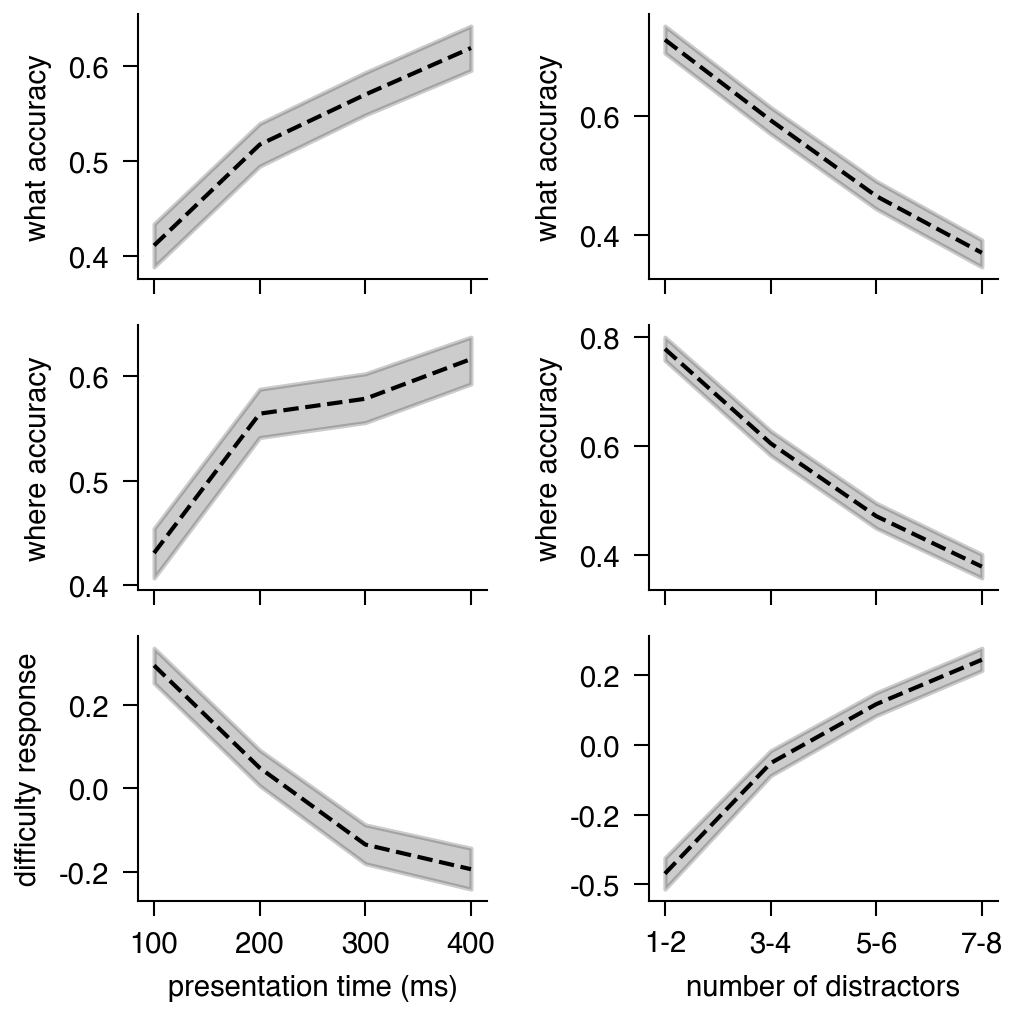

In [9]:
# human behavior only
fig, axs = plt.subplots(3, 2, figsize=cfg.plotting.figsize.square_single)
plot_behavioral_data(axs, human_df, model_df_plot=None)
plt.tight_layout()
fig.savefig(figures_dir / f"fig1b_human_behavior.pdf", bbox_inches="tight")
fig.savefig(figures_dir / f"fig1b_human_behavior.png", bbox_inches="tight")

# testing the effect of eccentricity on performance

if peripheral vision is playing a big role, then performance should go down when target has higher eccentricity


/tmp/ipykernel_2528265/3802366568.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=human_df,


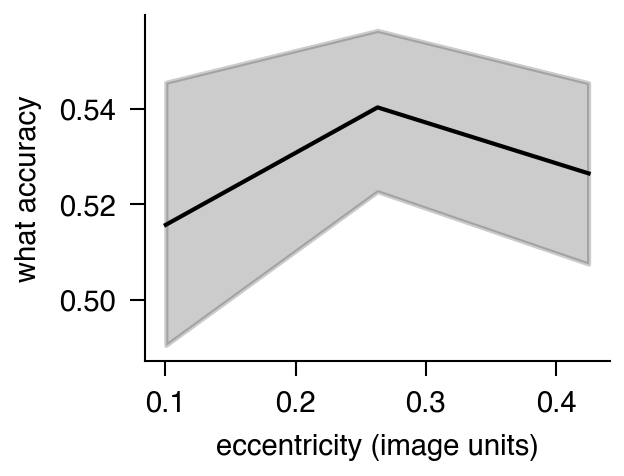

In [10]:

human_df["eccentricity"] = np.sqrt(human_df["where_x_ground_truth"] ** 2 + human_df["where_y_ground_truth"] ** 2)
eccentricity_bins = pd.cut(human_df["eccentricity"], bins=3, right=True)
human_df["eccentricity_bins"] = eccentricity_bins.apply(lambda x: (x.left + x.right) / 2)

hues = {
    "palette" : sns.color_palette("viridis", human_df["n_distractors"].nunique()),
}



fig, ax = plt.subplots(figsize=(2, 1.5))
sns.lineplot(data=human_df,
                x="eccentricity_bins",
                y="what_correct",
                **hues,
                errorbar=('ci', 95),
                linewidth=1,
                color="black",
                ax=ax,
)

ax.set_xlabel("eccentricity (image units)")
ax.set_ylabel("what accuracy")


fig.savefig(figures_dir / f"figS1_eccentricity_human.pdf", bbox_inches="tight")
fig.savefig(figures_dir / f"figS1_eccentricity_human.png", bbox_inches="tight")
None

# error consistency (Geirhos et al.)

In [11]:

def get_error_consistency(corrects_1, corrects_2):
    # expects boolean np arrays

    acc_1 = np.mean(corrects_1)
    acc_2 = np.mean(corrects_2)

    # observed error overlap
    c_obs = np.mean(corrects_1 == corrects_2)

    # expected error overlap by chance from decision makers with certain accuracies
    c_exp = acc_1 * acc_2 + (1 - acc_1) * (1 - acc_2)

    # error consistency
    kappa = (c_obs - c_exp) / (1 - c_exp)

    return kappa

    

In [12]:
human_df

,trial_index,dataset_index,presentation_time,n_distractors,noise,what_response,what_ground_truth,where_x_response,where_y_response,where_x_ground_truth,...,what_correct,where_error,trial_index_bin,participant_id,where_correct,noise_bin,n_distractors_bin,difficulty_z,eccentricity,eccentricity_bins
388,10,333,100,7,0.008526,9,1,-0.267857,-0.285714,0.148523,...,False,0.419309,"(0, 50]",P216739,False,0.049681,7.125,1.175115,0.279051,0.26300
389,11,238,200,7,0.028571,9,4,-0.084821,-0.209821,-0.101768,...,False,0.037553,"(0, 50]",P216739,True,0.049681,7.125,1.089626,0.203573,0.26300
390,12,276,200,6,0.155055,4,4,0.142857,0.022321,0.178665,...,True,0.053375,"(0, 50]",P216739,True,0.148600,5.375,-0.100104,0.179497,0.10045
391,13,354,300,7,0.121645,6,2,-0.191964,0.232143,-0.222017,...,False,0.038128,"(0, 50]",P216739,True,0.148600,7.125,0.875902,0.338566,0.26300
392,14,96,400,5,0.059707,7,6,0.017857,-0.071429,0.127090,...,False,0.192282,"(0, 50]",P216739,False,0.049681,5.375,0.384337,0.153910,0.10045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7458,394,267,100,4,0.045452,5,5,0.107060,0.127315,0.118435,...,True,0.020912,NaN,P329258,True,0.049681,3.625,0.401649,0.187115,0.26300
7459,395,86,400,2,0.071833,5,7,-0.040509,-0.312500,-0.246057,...,False,0.634717,NaN,P329258,False,0.049681,1.871,-0.587884,0.378808,0.42500
7460,396,117,300,1,0.103447,9,9,-0.295139,-0.355903,-0.298131,...,True,0.005146,NaN,P329258,True,0.148600,1.871,-1.352001,0.467489,0.42500
7461,397,291,300,2,0.020159,6,6,0.260417,0.243056,0.274283,...,True,0.051811,NaN,P329258,True,0.049681,1.871,-1.730240,0.401330,0.42500


In [13]:

# human to human error consistency
human_human_consistency = {"what": [], "where": []}
user_session_ids = human_df["user_session_id"].unique()

for i in range(len(user_session_ids)):
    for j in range(i+1, len(user_session_ids)):

        user_session_id_1 = user_session_ids[i]
        user_session_id_2 = user_session_ids[j]

        user_df_1 = human_df[human_df["user_session_id"] == user_session_id_1]
        user_df_2 = human_df[human_df["user_session_id"] == user_session_id_2]

        # sort according to dataset index
        user_df_1 = user_df_1.sort_values("dataset_index").reset_index(drop=True)
        user_df_2 = user_df_2.sort_values("dataset_index").reset_index(drop=True)

        common_indices = set(user_df_1["dataset_index"]) & set(user_df_2["dataset_index"])
        print(user_session_id_1, user_session_id_2, len(common_indices))

        user_df_1 = user_df_1[user_df_1["dataset_index"].isin(common_indices)]
        user_df_2 = user_df_2[user_df_2["dataset_index"].isin(common_indices)]

        what_corrects_1 = np.array(user_df_1["what_correct"].values, dtype=bool)
        what_corrects_2 = np.array(user_df_2["what_correct"].values, dtype=bool)

        where_corrects_1 = np.array(user_df_1["where_correct"].values, dtype=bool)
        where_corrects_2 = np.array(user_df_2["where_correct"].values, dtype=bool)

        what_kappa = get_error_consistency(what_corrects_1, what_corrects_2)
        where_kappa = get_error_consistency(where_corrects_1, where_corrects_2)

        human_human_consistency["what"].append(what_kappa)
        human_human_consistency["where"].append(where_kappa)
        



firstly-admittedly-fine-cardinal hopelessly-normally-busy-tahr 378
firstly-admittedly-fine-cardinal positively-largely-firm-beagle 378
firstly-admittedly-fine-cardinal needlessly-exactly-flowing-pelican 378
firstly-admittedly-fine-cardinal hardly-needlessly-flexible-goshawk 378
firstly-admittedly-fine-cardinal nominally-jolly-merry-griffon 378
firstly-admittedly-fine-cardinal finally-openly-alive-dog 378
firstly-admittedly-fine-cardinal entirely-personally-exciting-mule 378
firstly-admittedly-fine-cardinal fairly-barely-allowing-leech 378
firstly-admittedly-fine-cardinal partly-jolly-kind-crow 379
firstly-admittedly-fine-cardinal horribly-definitely-big-koala 379
firstly-admittedly-fine-cardinal reliably-repeatedly-thankful-whippet 378
firstly-admittedly-fine-cardinal neatly-slightly-regular-hog 378
firstly-admittedly-fine-cardinal carefully-repeatedly-gorgeous-penguin 378
firstly-admittedly-fine-cardinal genuinely-broadly-genuine-kid 378
firstly-admittedly-fine-cardinal pleasantly-wil

In [14]:
print(np.mean(human_human_consistency["what"]))
print(np.mean(human_human_consistency["where"]))

0.2456676139101113
0.21016742032161767


In [15]:
def get_model_human_consistency_df():
    energy_costs_list = []
    models_list = []
    model_names_list = []
    instances_list = []
    what_kappas_list = []
    where_kappas_list = []
    user_session_ids_list = []
    what_accuracy = []
    where_accuracy = []

    model_df_t = model_df[(model_df["t"] == model_df["t"].max())] # considering the last time step prediction only
		
    for model, model_name in zip(MODELS, MODEL_NAMES):
        for energy_cost in model_df_t["energy_cost"].unique():
            for instance in range(model_df_t["instance"].nunique()):
                sel = model_df_t["model"] == model # selecting the model
                sel &= model_df_t["instance"] == instance # selecting the instance
                sel &= model_df_t["energy_cost"] == energy_cost
                model_instance_df = model_df_t[sel]

                for user_session_id in user_session_ids:
                    print(model, energy_cost, instance, user_session_id)
                    user_df = human_df[human_df["user_session_id"] == user_session_id]
                    user_dataset_ids = user_df["dataset_index"].unique()

                    model_user_df = model_instance_df[model_instance_df["dataset_index"].isin(user_dataset_ids)]

                    # sort according to dataset index
                    user_df = user_df.sort_values("dataset_index").reset_index(drop=True)
                    model_user_df = model_user_df.sort_values("dataset_index").reset_index(drop=True)

                    what_corrects_1 = np.array(user_df["what_correct"].values, dtype=bool)
                    what_corrects_2 = np.array(model_user_df["what_correct"].values, dtype=bool)

                    where_corrects_1 = np.array(user_df["where_correct"].values, dtype=bool)
                    where_corrects_2 = np.array(model_user_df["where_correct"].values, dtype=bool)

                    what_kappa = get_error_consistency(what_corrects_1, what_corrects_2)
                    where_kappa = get_error_consistency(where_corrects_1, where_corrects_2)
                    
                    energy_costs_list.append(float(energy_cost))
                    models_list.append(model)
                    model_names_list.append(model_name)
                    instances_list.append(instance)
                    user_session_ids_list.append(user_session_id)
                    what_kappas_list.append(what_kappa)
                    where_kappas_list.append(where_kappa)
                    
                    what_accuracy.append(np.mean(what_corrects_2))
                    where_accuracy.append(np.mean(where_corrects_2))


    consistency_df = pd.DataFrame({"energy_cost": energy_costs_list,
                                   "model": models_list,
                                   "model_name": model_names_list,
                                   "instance": instances_list,
                                   "user_session_id": user_session_ids_list,
                                   "what_kappa": what_kappas_list,
                                   "where_kappa": where_kappas_list,
                                   "what_accuracy": what_accuracy,
                                   "where_accuracy": where_accuracy,
                                   })

    return consistency_df

if (results_dir / "model_human_consistency.csv").exists() and not cfg.plotting.behavioral_results.error_consistency.redo:
	consistency_df = pd.read_csv(results_dir / "model_human_consistency.csv")
else:
    consistency_df = get_model_human_consistency_df()
    consistency_df.to_csv(results_dir / "model_human_consistency.csv", index=False)

# binning energy cost
bins = pd.cut(consistency_df["energy_cost"], bins=cfg.plotting.behavioral_results.n_energy_cost_bins)
consistency_df["energy_cost_bin"] = bins.apply(lambda x: (x.left + x.right) / 2)
print(len(consistency_df["energy_cost_bin"].unique()))
consistency_df

16


,energy_cost,experiment,model,model_name,instance,user_session_id,what_kappa,where_kappa,what_accuracy,where_accuracy,energy_cost_bin
0,-6.0,journal_flexible,baseline,baseline,0,firstly-admittedly-fine-cardinal,0.102040,0.142886,0.388175,0.514139,-6.1875
1,-6.0,journal_flexible,baseline,baseline,0,hopelessly-normally-busy-tahr,0.011690,0.115769,0.388175,0.501285,-6.1875
2,-6.0,journal_flexible,baseline,baseline,0,positively-largely-firm-beagle,0.051540,0.058212,0.385604,0.508997,-6.1875
3,-6.0,journal_flexible,baseline,baseline,0,needlessly-exactly-flowing-pelican,0.134192,0.164631,0.385604,0.506427,-6.1875
4,-6.0,journal_flexible,baseline,baseline,0,hardly-needlessly-flexible-goshawk,0.016402,0.073295,0.388175,0.506427,-6.1875
...,...,...,...,...,...,...,...,...,...,...,...
44995,-12.0,journal_flexible,ean_full,EAN-full,4,carefully-repeatedly-gorgeous-penguin,0.180056,0.199006,0.699229,0.668380,-11.8155
44996,-12.0,journal_flexible,ean_full,EAN-full,4,genuinely-broadly-genuine-kid,0.125989,0.184322,0.701799,0.663239,-11.8155
44997,-12.0,journal_flexible,ean_full,EAN-full,4,pleasantly-wildly-enabling-dory,0.154827,0.100254,0.701799,0.668380,-11.8155
44998,-12.0,journal_flexible,ean_full,EAN-full,4,trivially-tightly-exciting-monkfish,0.198903,0.219453,0.694087,0.655527,-11.8155


In [16]:
# print energy cost for which there is max consistency
consistency_means = consistency_df.groupby(["model", "energy_cost_bin"]).mean(numeric_only=True).reset_index()
# consistency_means = consistency_df.groupby(["model", "energy_cost"]).mean(numeric_only=True).reset_index()

# for every model, print the energy cost for which the what and where kappa is max
for model in consistency_means["model"].unique():
    print(f"Model: {model}")
    print("What max energy cost:", consistency_means[consistency_means["model"] == model]["energy_cost_bin"][consistency_means[consistency_means["model"] == model]["what_kappa"].idxmax()])
    print("Where max energy cost:", consistency_means[consistency_means["model"] == model]["energy_cost_bin"][consistency_means[consistency_means["model"] == model]["where_kappa"].idxmax()])

    print("What max kappa:", consistency_means[consistency_means["model"] == model]["what_kappa"].max())
    print("Where max kappa:", consistency_means[consistency_means["model"] == model]["where_kappa"].max())

    print()

energy_cost_consistency_peak_ean_full = {}
for task in ["what", "where"]:
    energy_cost_consistency_peak_ean_full[task] = consistency_means[consistency_means["model"] == "ean_full"]["energy_cost_bin"][consistency_means[consistency_means["model"] == "ean_full"][f"{task}_kappa"].idxmax()]
print(energy_cost_consistency_peak_ean_full)

Model: baseline
What max energy cost: -6.1875
Where max energy cost: -6.9375
What max kappa: 0.09136075466858601
Where max kappa: 0.15774149952988695

Model: ean_features
What max energy cost: -8.4375
Where max energy cost: -8.0625
What max kappa: 0.15535915314608092
Where max kappa: 0.1727298109763804

Model: ean_full
What max energy cost: -7.6875
Where max energy cost: -6.5625
What max kappa: 0.16858819342440842
Where max kappa: 0.19358991934448566

Model: ean_global
What max energy cost: -9.5625
Where max energy cost: -9.1875
What max kappa: 0.12054383043867642
Where max kappa: 0.16797845382004306

Model: ean_space
What max energy cost: -9.1875
Where max energy cost: -6.5625
What max kappa: 0.1622398420873263
Where max kappa: 0.17536492933967582

{'what': np.float64(-7.6875), 'where': np.float64(-6.5625)}


/tmp/ipykernel_2528265/1286127550.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  consistency_means = consistency_df.groupby(["model", "energy_cost_bin"]).mean(numeric_only=True).reset_index()


In [17]:
bins = pd.cut(image_df["energy_cost"], bins=cfg.plotting.behavioral_results.n_energy_cost_bins)
image_df["energy_cost_bin"] = bins.apply(lambda x: (x.left + x.right) / 2)

In [18]:
sample_sizes = image_df.groupby(['model_name', 'energy_cost_bin']).size()
print(sample_sizes)

model_name   energy_cost_bin
EAN-feature  -11.8155           14000
             -11.4375           12000
             -11.0625           12000
             -10.6875           12000
             -10.3125           12000
                                ...  
baseline     -7.6875            12000
             -7.3125            12000
             -6.9375            12000
             -6.5625            12000
             -6.1875            14000
Length: 80, dtype: int64


/tmp/ipykernel_2528265/2816491526.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_sizes = image_df.groupby(['model_name', 'energy_cost_bin']).size()


In [19]:
image_df

,experiment,model,model_name,energy_cost,instance,dataset_index,what_correct_model,where_correct_model,where_error_model,what_entropy,...,log_energy,log_baseline_energy,energy_cost_str,what_correct_human,where_correct_human,where_error_human,difficulty_z,n_distractors,noise,energy_cost_bin
0,journal_flexible,baseline,baseline,-12.0,0,0,0.0,False,0.197836,1.837389,...,9.868342,8.485746,-12.,0.764706,0.941176,0.065408,-0.562166,1,0.051924,-11.8155
1,journal_flexible,baseline,baseline,-12.0,0,1,0.0,False,0.642979,1.993954,...,10.282507,8.893805,-12.,0.117647,0.235294,0.376906,0.781235,8,0.039317,-11.8155
2,journal_flexible,baseline,baseline,-12.0,0,2,0.0,True,0.036046,2.044099,...,9.943623,8.550563,-12.,0.722222,0.777778,0.113547,-0.238289,3,0.005226,-11.8155
3,journal_flexible,baseline,baseline,-12.0,0,3,1.0,True,0.053031,1.236738,...,9.806857,8.417991,-12.,0.722222,0.666667,0.193539,-0.048308,3,0.022040,-11.8155
4,journal_flexible,baseline,baseline,-12.0,0,4,0.0,False,0.448213,2.044582,...,10.570574,9.182273,-12.,0.111111,0.222222,0.255088,0.724915,8,0.186451,-11.8155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,journal_flexible,ean_space,EAN-spatial,-6.0,4,395,0.0,False,0.124290,2.110734,...,10.034640,8.596761,-6.,0.588235,0.411765,0.320051,0.345567,4,0.036197,-6.1875
999996,journal_flexible,ean_space,EAN-spatial,-6.0,4,396,0.0,False,0.414385,2.201744,...,10.238156,8.868463,-6.,0.777778,0.833333,0.107078,-0.179142,1,0.193634,-6.1875
999997,journal_flexible,ean_space,EAN-spatial,-6.0,4,397,0.0,True,0.068690,2.229863,...,10.210895,8.769558,-6.,0.117647,0.176471,0.281694,0.540383,8,0.072410,-6.1875
999998,journal_flexible,ean_space,EAN-spatial,-6.0,4,398,1.0,True,0.018018,1.265883,...,10.153428,8.722120,-6.,0.777778,0.777778,0.163432,0.035532,3,0.092594,-6.1875


In [20]:
from joblib import Parallel, delayed
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd

def fit_lr_model(X, y, predictors):
    """
    Fit a linear regression model with the given predictors.
    """
    X_scaled = sm.add_constant(X[predictors])
    model = sm.OLS(y, X_scaled).fit()
    return model

def bootstrap_single_iteration(group, i, n_samples, all_predictors, outcome, 
                                lr_model_predictors, r2_results):
    """
    Single bootstrap iteration - can be parallelized.
    
    Parameters:
    -----------
    group : DataFrame
        The data group to bootstrap from
    i : int
        Random seed for this bootstrap iteration
    n_samples : int
        Number of samples to draw
    all_predictors : list
        List of all predictor column names
    outcome : str
        Name of outcome variable
    lr_model_predictors : dict
        Dictionary mapping model names to their predictor lists
    r2_results : dict
        Dictionary defining which R² values to compute
    
    Returns:
    --------
    dict : R² values for this bootstrap iteration
    """
    # Resample with replacement
    boot_sample = resample(group, n_samples=n_samples, random_state=i)
    boot_sample = boot_sample.reset_index(drop=True)
    
    # Scale predictors
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(boot_sample[all_predictors]),
        columns=all_predictors
    )
    y = boot_sample[outcome]
    
    # Fit all models
    lr_models = {}
    for lr_model_name, predictors in lr_model_predictors.items():
        lr_models[lr_model_name] = fit_lr_model(X_scaled, y, predictors)
    
    # Compute R² values
    iteration_results = {}
    for key, (lr_model_name, lr_baseline_model_name) in r2_results.items():
        r2 = lr_models[lr_model_name].rsquared
        if lr_baseline_model_name is not None:
            # Subtract baseline R² to get additional variance explained
            r2 -= lr_models[lr_baseline_model_name].rsquared
        iteration_results[key] = r2
    
    return iteration_results

def get_bootstrap_difficulty_df(image_df, n_bootstraps=1000, n_samples=3000, n_jobs=-1):
    """
    Bootstrap R² analysis of difficulty judgments with parallelization.
    
    Parameters:
    -----------
    image_df : DataFrame
        Input data with columns for predictors, outcome, model_name, and energy_cost_bin
    n_bootstraps : int
        Number of bootstrap iterations (default: 1000)
    n_samples : int
        Number of samples per bootstrap (default: 3000)
    n_jobs : int
        Number of parallel jobs. -1 uses all available cores (default: -1)
    
    Returns:
    --------
    DataFrame : Bootstrap results with R² values for each iteration
    """
    dfs = []
    
    # Define predictors and models (these should be defined globally or passed in)
    # all_predictors = ['n_distractors', 'noise', 'log_energy', 'what_entropy_z', 'where_entropy_z']
    all_predictors = ['n_distractors', 'noise', 'log_energy', 'what_entropy', 'where_entropy']
    outcome = 'difficulty_z'
    
    lr_model_predictors = {
        # baselines
        "noise_baseline": ["noise"],
        "n_distractors_baseline": ["n_distractors"],
        "baseline": ["n_distractors", "noise"],
        # energy (with baseline)
        "energy": ["log_energy"],
        "energy_with_baseline": ["noise", "n_distractors", "log_energy"],
        # entropy (with baseline)
        # "entropy": ["what_entropy_z", "where_entropy_z"],
        "entropy": ["what_entropy", "where_entropy"],
        # "entropy_with_baseline": ["noise", "n_distractors", "what_entropy_z", "where_entropy_z"],
        "entropy_with_baseline": ["noise", "n_distractors", "what_entropy", "where_entropy"],
        # full
        "full": all_predictors,
    }
    
    r2_results = {
        "noise_r2": ("noise_baseline", None),
        "n_distractors_r2": ("n_distractors_baseline", None),
        "n_distractors_noise_r2": ("baseline", None),
        "energy_r2": ("energy", None),
        "energy_beyond_baseline_r2": ("energy_with_baseline", "baseline"),
        "entropy_r2": ("entropy", None),
        "entropy_beyond_baseline_r2": ("entropy_with_baseline", "baseline"),
        "full_r2": ("full", None),
        "full_beyond_baseline_r2": ("full", "baseline"),
    }
    
    # Process each group
    for (model, energy_cost_bin), group in image_df.groupby(['model_name', 'energy_cost_bin']):
        print(f"Processing: {model}, {energy_cost_bin}")
        
        # Parallel bootstrap iterations
        bootstrap_results = Parallel(n_jobs=n_jobs, verbose=0, batch_size='auto')(
            delayed(bootstrap_single_iteration)(
                group, i, n_samples, all_predictors, outcome, 
                lr_model_predictors, r2_results
            )
            for i in range(n_bootstraps)
        )
        
        # Convert list of dicts to DataFrame
        bootstrap_df = pd.DataFrame(bootstrap_results)
        bootstrap_df['model_name'] = model
        bootstrap_df['energy_cost_bin'] = energy_cost_bin
        dfs.append(bootstrap_df)
    
    # Concatenate all bootstrap results
    bootstrap_difficulty_df = pd.concat(dfs, ignore_index=True)
    return bootstrap_difficulty_df


path = results_dir / "bootstrap_difficulty_df.csv"
if path.exists() and not cfg.plotting.behavioral_results.difficulty.redo:
    bootstrap_difficulty_df = pd.read_csv(path)
else:
    bootstrap_difficulty_df = get_bootstrap_difficulty_df(
        image_df, 
        n_bootstraps=cfg.plotting.behavioral_results.difficulty.n_bootstraps,
        n_jobs=-1
    )
    bootstrap_difficulty_df.to_csv(path, index=False)

bootstrap_difficulty_df.head()

,noise_r2,n_distractors_r2,n_distractors_noise_r2,energy_r2,energy_beyond_baseline_r2,entropy_r2,entropy_beyond_baseline_r2,full_r2,full_beyond_baseline_r2,model_name,energy_cost_bin
0,0.037753,0.369010,0.406099,0.333331,0.014920,0.198136,0.016225,0.433379,0.027281,EAN-feature,-11.8155
1,0.033013,0.365768,0.406258,0.322909,0.011261,0.196821,0.025264,0.437370,0.031112,EAN-feature,-11.8155
2,0.027009,0.355785,0.388116,0.287739,0.006714,0.175461,0.015519,0.407819,0.019703,EAN-feature,-11.8155
3,0.031927,0.315233,0.350889,0.280864,0.011101,0.177893,0.024556,0.382167,0.031278,EAN-feature,-11.8155
4,0.043620,0.345664,0.385625,0.321125,0.014457,0.204879,0.028132,0.422333,0.036708,EAN-feature,-11.8155


In [21]:
bootstrap_difficulty_df

,noise_r2,n_distractors_r2,n_distractors_noise_r2,energy_r2,energy_beyond_baseline_r2,entropy_r2,entropy_beyond_baseline_r2,full_r2,full_beyond_baseline_r2,model_name,energy_cost_bin
0,0.037753,0.369010,0.406099,0.333331,0.014920,0.198136,0.016225,0.433379,0.027281,EAN-feature,-11.8155
1,0.033013,0.365768,0.406258,0.322909,0.011261,0.196821,0.025264,0.437370,0.031112,EAN-feature,-11.8155
2,0.027009,0.355785,0.388116,0.287739,0.006714,0.175461,0.015519,0.407819,0.019703,EAN-feature,-11.8155
3,0.031927,0.315233,0.350889,0.280864,0.011101,0.177893,0.024556,0.382167,0.031278,EAN-feature,-11.8155
4,0.043620,0.345664,0.385625,0.321125,0.014457,0.204879,0.028132,0.422333,0.036708,EAN-feature,-11.8155
...,...,...,...,...,...,...,...,...,...,...,...
79995,0.036421,0.366431,0.401553,0.252608,0.009843,0.221973,0.023812,0.433703,0.032150,baseline,-6.1875
79996,0.031780,0.371064,0.402723,0.252009,0.008913,0.239983,0.025433,0.436790,0.034067,baseline,-6.1875
79997,0.031078,0.335687,0.370684,0.230952,0.008044,0.216685,0.028318,0.406201,0.035517,baseline,-6.1875
79998,0.035344,0.333883,0.374864,0.242932,0.008882,0.212315,0.025295,0.408631,0.033768,baseline,-6.1875


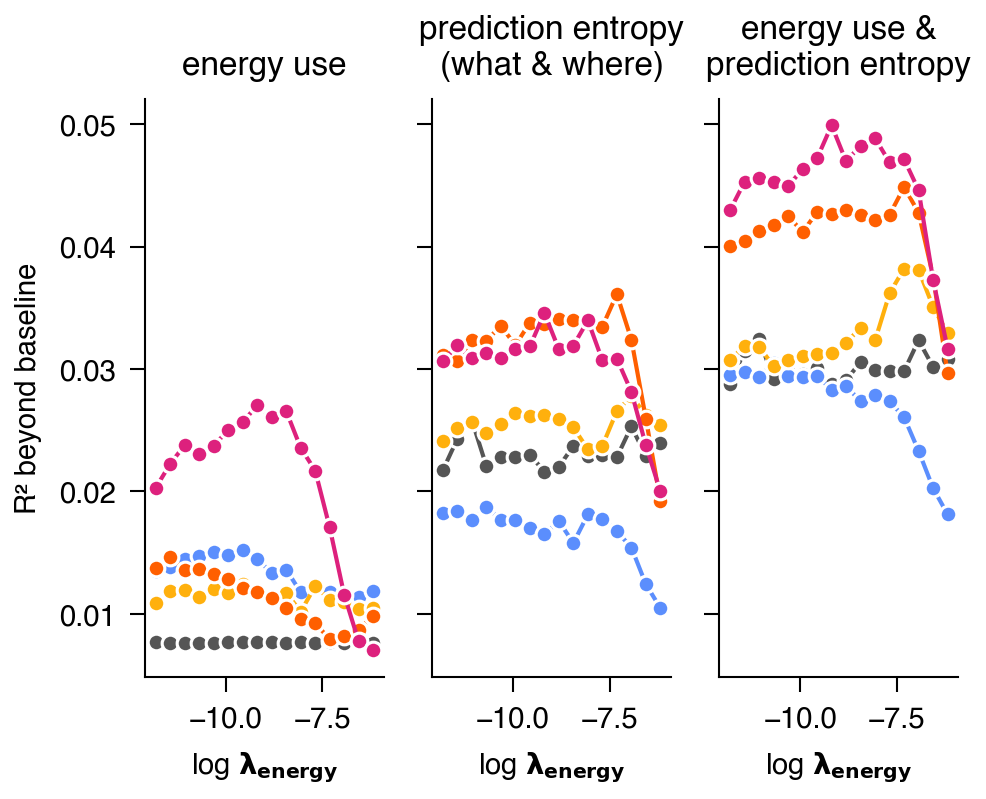

In [22]:
fig, axs = plt.subplots(1, 3, figsize=cfg.plotting.figsize.single_column, sharey=True)

def plot_r2_result(result_key, ax):
    # Calculate confidence intervals first
    bootstrap_summary = bootstrap_difficulty_df.groupby(['model_name', 'energy_cost_bin']).agg({
        # 'full_beyond_baseline_r2': [
        result_key: [
            'mean',
            lambda x: np.percentile(x, 2.5),
            lambda x: np.percentile(x, 97.5)
        ]
    }).reset_index()

    bootstrap_summary.columns = ['model_name', 'energy_cost_bin', 'mean', 'ci_lower', 'ci_upper']

    # Calculate error bar sizes
    bootstrap_summary['yerr_lower'] = bootstrap_summary['mean'] - bootstrap_summary['ci_lower']
    bootstrap_summary['yerr_upper'] = bootstrap_summary['ci_upper'] - bootstrap_summary['mean']

    for (i, model) in enumerate(MODELS):
        model_data = bootstrap_summary[bootstrap_summary['model_name'] == MODEL_NAMES[i]]
        
        # Error bars need to be in format [lower_errors, upper_errors]
        yerr = [model_data['yerr_lower'].values, model_data['yerr_upper'].values]

        # x = model_data['energy_cost_bin'] + 0.05 * (i-2)  # slight offset for visibility
        x = model_data['energy_cost_bin']
        
        # ax.errorbar(x, model_data['mean'], yerr=yerr, color=seaborn_colors['palette'][i], linewidth=1, marker='o', markersize=4, capsize=3, capthick=1,)
        sns.lineplot(x=x, y=model_data['mean'], color=seaborn_colors['palette'][i], linewidth=1, marker='o', markersize=4, ax=ax, label=MODEL_NAMES[i])

    ax.set_xlabel('log ' +  r'$\mathbf{\lambda_{energy}}$')
    ax.set_ylabel('R² beyond baseline')
    ax.legend().remove()
    # plt.show()

plot_r2_result("energy_beyond_baseline_r2", axs[0])
plot_r2_result("entropy_beyond_baseline_r2", axs[1])
plot_r2_result("full_beyond_baseline_r2", axs[2])

axs[0].set_title("energy use")
axs[1].set_title("prediction entropy\n(what & where)")
axs[2].set_title("energy use &\nprediction entropy")

fig.savefig(figures_dir / f"figS2_energy_cost_additional_r2.png", bbox_inches="tight", dpi=500)
fig.savefig(figures_dir / f"figS2_energy_cost_additional_r2.pdf", bbox_inches="tight", dpi=500)

noise_r2 0.035224705815965936 0.022939131442077983 0.04963762937420257
n_distractors_r2 0.3516917160230495 0.323744830228507 0.3796499393637714
n_distractors_noise_r2 0.38843818542966935 0.36118460870877633 0.4151897135785065


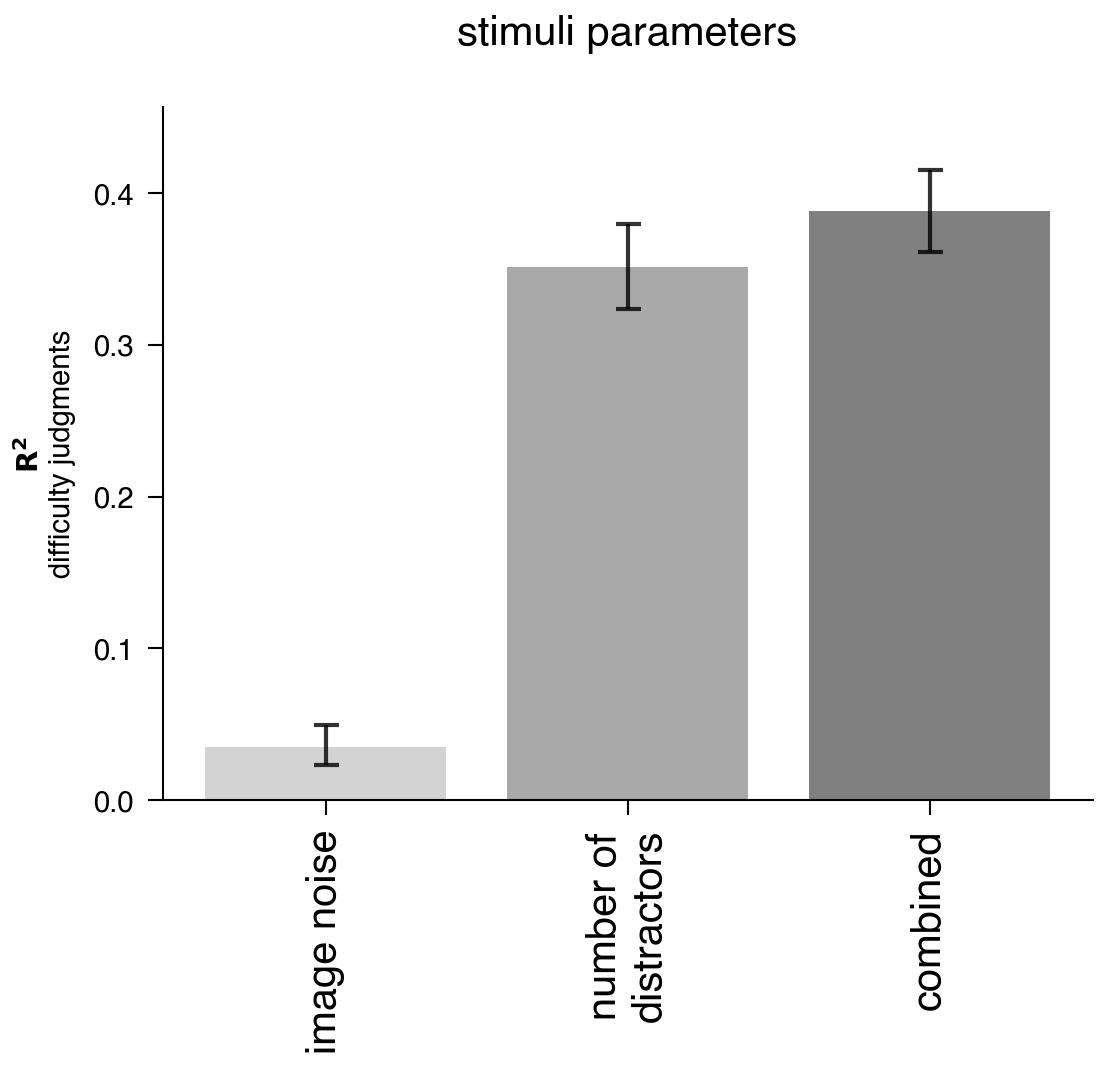

In [23]:
def plot_baseline_variance_barplot(ax, difficulty_analysis_df):
    """
    Create barplot showing variance explained by baseline image properties
    """
    
    # Calculate means and CIs across all energy costs and models
    metrics = ['noise_r2', 'n_distractors_r2', 'n_distractors_noise_r2']
    labels = ['image noise', 'number of\ndistractors', 'combined']

    means = []
    ci_lowers = []
    ci_uppers = []
    
    for metric in metrics:
        values = difficulty_analysis_df[metric]
        mean_val = values.mean()
        ci_lower = np.percentile(values, 2.5)
        ci_upper = np.percentile(values, 97.5)
        
        means.append(mean_val)
        ci_lowers.append(ci_lower)
        ci_uppers.append(ci_upper)

        print(metric, mean_val, ci_lower, ci_upper)
    
    # Calculate error bars (distance from mean to CI bounds)
    yerr_lower = np.array(means) - np.array(ci_lowers)
    yerr_upper = np.array(ci_uppers) - np.array(means)
    yerr = [yerr_lower, yerr_upper]
    
    colors = ["lightgray", "darkgray", "gray"]

    # Create bars
    bars = ax.bar(range(len(metrics)), means, 
                  color=colors, alpha=1.0,
                  yerr=yerr, capsize=3, 
                  error_kw={'linewidth': 1, 'alpha': 0.8})
    
    # Formatting
    ax.set_title('stimuli parameters', pad=15, fontsize=cfg.plotting.behavioral_results.difficulty.xlabel_fontsize)

    # ax.set_ylabel('R² difficulty judgments')
    ax.set_ylabel(r'$\mathbf{R^2}$' + '\ndifficulty judgments')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=cfg.plotting.behavioral_results.difficulty.xlabel_fontsize)
    ax.set_ylim(0, max(ci_uppers) * 1.1)  # Add some headroom
    
    # Add value labels on top of bars
    # for i, (bar, mean, ci_upper) in enumerate(zip(bars, means, ci_uppers)):
    #     height = ci_upper + (max(ci_uppers) * 0.02)  # Slightly above error bar
    #     ax.text(bar.get_x() + bar.get_width()/2., height, f'{mean:.3f}', ha='center', va='bottom',
    #             fontsize=cfg.plotting.behavioral_results.difficulty.r2_fontsize)
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

# Usage:
fig, ax = plt.subplots(figsize=(4,3))
plot_baseline_variance_barplot(ax, bootstrap_difficulty_df)

In [24]:
import numpy as np
import pandas as pd
from scipy import stats


def get_argmaxed_values(df, model_name, metric, verbose=True):
    """
    Get bootstrap values for the energy bin with maximum mean metric.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Bootstrap dataframe with model_name, energy_cost_bin, and metric columns
    model_name : str
        Name of the model to extract data for
    metric : str
        Name of the metric column (e.g., 'full_beyond_baseline_r2')
    
    Returns:
    --------
    pd.Series : Bootstrap values at the optimal energy bin
    """
    model_data = df[df["model_name"] == model_name]
    
    # Find energy bin with maximum mean metric
    energy_cost_bin_metric_mean = (
        model_data.groupby("energy_cost_bin")[metric]
        .mean()
        .reset_index()
    )
    energy_cost_bin_metric_mean.columns = ["energy_cost_bin", f"{metric}_mean"]
    
    idx_max = np.argmax(energy_cost_bin_metric_mean[f"{metric}_mean"])
    max_energy_cost_bin = energy_cost_bin_metric_mean["energy_cost_bin"].values[idx_max]
    
    if verbose:
        max_mean = energy_cost_bin_metric_mean[f"{metric}_mean"].values[idx_max]
        print(f"Model: {model_name}, Max {metric} at energy bin {max_energy_cost_bin} with mean {max_mean:.4f}")
    
    # Get all bootstrap values at this energy bin
    values = model_data[model_data["energy_cost_bin"] == max_energy_cost_bin][metric]
    
    return values


def bootstrap_difference_test(bootstrap_difficulty_df, metric, alpha=0.05, 
                              correction='bonferroni', verbose=True):
    """
    Test if models differ significantly using bootstrap distributions.
    
    Tests whether the difference in R² between two models is significantly
    different from zero, using the bootstrap distribution of differences.
    
    Parameters:
    -----------
    bootstrap_difficulty_df : pd.DataFrame
        DataFrame with columns: model_name, energy_cost_bin, and metric
    metric : str
        Name of the metric to test (e.g., 'full_beyond_baseline_r2')
    alpha : float
        Significance level (default: 0.05 for 95% confidence)
    correction : str
        Multiple testing correction: 'bonferroni', 'fdr_bh', or 'none'
    verbose : bool
        Whether to print detailed results
    
    Returns:
    --------
    pd.DataFrame : Results for each pairwise comparison with columns:
        - model1, model2: Models being compared
        - observed_diff: Mean difference in metric
        - ci_lower, ci_upper: Confidence interval for difference
        - p_value: Two-tailed p-value
        - significant: Whether difference is significant
        - cohens_d: Effect size
        - n_bootstrap: Number of bootstrap samples
    """
    
    results = []
    models = sorted(bootstrap_difficulty_df['model_name'].unique())
    n_models = len(models)
    
    if verbose:
        print(f"\n{'='*70}")
        print(f"Bootstrap Difference Test for: {metric}")
        print(f"{'='*70}")
        print(f"Number of models: {n_models}")
        print(f"Number of comparisons to baseline: {n_models - 1}")
        print(f"Significance level: α = {alpha}")
        print(f"\nFinding optimal energy bins for each model:")
    
    # Get bootstrap distributions for each model at their optimal energy bin
    model_distributions = {}
    for model in models:
        model_distributions[model] = get_argmaxed_values(
            bootstrap_difficulty_df, model, metric
        )
    
    if verbose:
        print(f"\nRunning comparisons against baseline...")
    
    # Perform comparisons against baseline only
    baseline_model = "baseline"
    
    for model in models:
        if model == baseline_model:
            continue  # Skip comparing baseline to itself
        
        model1, model2 = model, baseline_model
        
        # Get bootstrap distributions
        dist1 = model_distributions[model1].values
        dist2 = model_distributions[model2].values

        # Calculate difference distribution (for paired data)
        diff_distribution = dist1 - dist2
        observed_diff = np.mean(diff_distribution)

        # Get 95% CI
        ci_lower = np.percentile(diff_distribution, 2.5)
        ci_upper = np.percentile(diff_distribution, 97.5)

        # Significance test (from CI)
        significant = not (ci_lower <= 0 <= ci_upper)

        # P-value calculation (using bootstrap SE)
        se_diff = np.std(diff_distribution, ddof=1)
        if se_diff > 0:
            z_score = observed_diff / se_diff
            p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
        else:
            p_value = 1.0  # No variance = no difference 
        
        # Calculate effect size (Cohen's d)
        pooled_std = np.sqrt((np.var(dist1) + np.var(dist2)) / 2)
        cohens_d = observed_diff / pooled_std if pooled_std > 0 else 0
        
        # Store results
        results.append({
            'model1': model1,
            'model2': model2,
            'observed_diff': observed_diff,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'p_value': p_value,
            'significant': significant,
            'cohens_d': cohens_d,
            'n_bootstrap': len(diff_distribution),
            'mean_model1': np.mean(dist1),
            'mean_model2': np.mean(dist2),
            'std_model1': np.std(dist1),
            'std_model2': np.std(dist2)
        })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Apply multiple testing correction
    n_tests = len(results_df)
    p_values = results_df['p_value'].values
    
    if correction == 'bonferroni':
        corrected_p = np.minimum(p_values * n_tests, 1.0)
        correction_name = 'Bonferroni'
    elif correction == 'fdr_bh':
        from statsmodels.stats.multitest import multipletests
        corrected_p = multipletests(p_values, method='fdr_bh', alpha=alpha)[1]
        correction_name = 'FDR (Benjamini-Hochberg)'
    else:
        corrected_p = p_values
        correction_name = 'None'
    
    results_df['p_value_corrected'] = corrected_p
    results_df['significant_corrected'] = corrected_p < alpha
    results_df['correction_method'] = correction_name
    
    # Print summary
    if verbose:
        print(f"\n{'='*70}")
        print(f"RESULTS SUMMARY")
        print(f"{'='*70}")
        print(f"Comparing all models to: {baseline_model}")
        print(f"Correction method: {correction_name}")
        print(f"Significant comparisons (uncorrected): "
              f"{np.sum(results_df['significant'])}/{n_tests}")
        print(f"Significant comparisons (corrected): "
              f"{np.sum(results_df['significant_corrected'])}/{n_tests}")
        
        if np.sum(results_df['significant_corrected']) > 0:
            print(f"\n{'='*70}")
            print(f"SIGNIFICANT DIFFERENCES (after {correction_name} correction)")
            print(f"{'='*70}")
            
            sig_results = results_df[results_df['significant_corrected']].copy()
            sig_results = sig_results.sort_values('observed_diff', ascending=False)
            
            for idx, row in sig_results.iterrows():
                print(f"\n{row['model1']} vs {row['model2']}:")
                print(f"  Difference: {row['observed_diff']:+.4f}")
                print(f"  95% CI: [{row['ci_lower']:+.4f}, {row['ci_upper']:+.4f}]")
                print(f"  p-value (corrected): {row['p_value_corrected']:.4f}")
                print(f"  Cohen's d: {row['cohens_d']:+.2f}")
                
                # Interpret effect size
                abs_d = abs(row['cohens_d'])
                if abs_d < 0.2:
                    effect = "negligible"
                elif abs_d < 0.5:
                    effect = "small"
                elif abs_d < 0.8:
                    effect = "medium"
                else:
                    effect = "large"
                print(f"  Effect size: {effect}")
        else:
            print(f"\nNo significant differences found after correction.")
        
        print(f"\n{'='*70}\n")
    
    return results_df



# Run the test
difficulty_statistical_test_results = {}

for metric in ["energy_beyond_baseline_r2", "entropy_beyond_baseline_r2", "full_beyond_baseline_r2"]:
    print("\n" + "="*70)
    print(f"Testing metric: {metric}")
    print("="*70)
    
    results = bootstrap_difference_test(
        bootstrap_difficulty_df, 
        metric=metric,
        alpha=0.05,
        correction='bonferroni',
        verbose=True
    )
    
    difficulty_statistical_test_results[metric] = results


Testing metric: energy_beyond_baseline_r2

Bootstrap Difference Test for: energy_beyond_baseline_r2
Number of models: 5
Number of comparisons to baseline: 4
Significance level: α = 0.05

Finding optimal energy bins for each model:
Model: EAN-feature, Max energy_beyond_baseline_r2 at energy bin -9.5625 with mean 0.0124
Model: EAN-full, Max energy_beyond_baseline_r2 at energy bin -9.1875 with mean 0.0271
Model: EAN-global, Max energy_beyond_baseline_r2 at energy bin -9.5625 with mean 0.0152
Model: EAN-spatial, Max energy_beyond_baseline_r2 at energy bin -11.4375 with mean 0.0147
Model: baseline, Max energy_beyond_baseline_r2 at energy bin -9.5625 with mean 0.0077

Running comparisons against baseline...

RESULTS SUMMARY
Comparing all models to: baseline
Correction method: Bonferroni
Significant comparisons (uncorrected): 4/4
Significant comparisons (corrected): 3/4

SIGNIFICANT DIFFERENCES (after Bonferroni correction)

EAN-full vs baseline:
  Difference: +0.0193
  95% CI: [+0.0136, +0.

In [25]:
keys_included = ['model1', 'model2', 'p_value_corrected']

for metric in ["energy_beyond_baseline_r2", "entropy_beyond_baseline_r2", "full_beyond_baseline_r2"]:
    print("\n" + "="*70)
    print(f"Results for metric: {metric}")
    print("="*70)
    print(difficulty_statistical_test_results[metric][keys_included])


Results for metric: energy_beyond_baseline_r2
        model1    model2  p_value_corrected
0  EAN-feature  baseline       1.767921e-01
1     EAN-full  baseline       1.361387e-09
2   EAN-global  baseline       1.139917e-05
3  EAN-spatial  baseline       7.580204e-05

Results for metric: entropy_beyond_baseline_r2
        model1    model2  p_value_corrected
0  EAN-feature  baseline           1.000000
1     EAN-full  baseline           0.489725
2   EAN-global  baseline           0.331890
3  EAN-spatial  baseline           0.164367

Results for metric: full_beyond_baseline_r2
        model1    model2  p_value_corrected
0  EAN-feature  baseline           0.940740
1     EAN-full  baseline           0.007253
2   EAN-global  baseline           1.000000
3  EAN-spatial  baseline           0.045859


energy_beyond_baseline_r2 baseline mean_val: 0.0077, CI: [0.0034, 0.0132]
energy_beyond_baseline_r2 EAN-global mean_val: 0.0152, CI: [0.0090, 0.0225]
energy_beyond_baseline_r2 EAN-feature mean_val: 0.0124, CI: [0.0071, 0.0191]
energy_beyond_baseline_r2 EAN-spatial mean_val: 0.0147, CI: [0.0086, 0.0220]
energy_beyond_baseline_r2 EAN-full mean_val: 0.0271, CI: [0.0191, 0.0368]
entropy_beyond_baseline_r2 baseline mean_val: 0.0258, CI: [0.0170, 0.0360]
entropy_beyond_baseline_r2 EAN-global mean_val: 0.0188, CI: [0.0120, 0.0273]
entropy_beyond_baseline_r2 EAN-feature mean_val: 0.0278, CI: [0.0190, 0.0371]
entropy_beyond_baseline_r2 EAN-spatial mean_val: 0.0361, CI: [0.0258, 0.0470]
entropy_beyond_baseline_r2 EAN-full mean_val: 0.0346, CI: [0.0249, 0.0455]
full_beyond_baseline_r2 baseline mean_val: 0.0324, CI: [0.0225, 0.0427]
full_beyond_baseline_r2 EAN-global mean_val: 0.0305, CI: [0.0213, 0.0401]
full_beyond_baseline_r2 EAN-feature mean_val: 0.0382, CI: [0.0281, 0.0495]
full_beyond_baseli

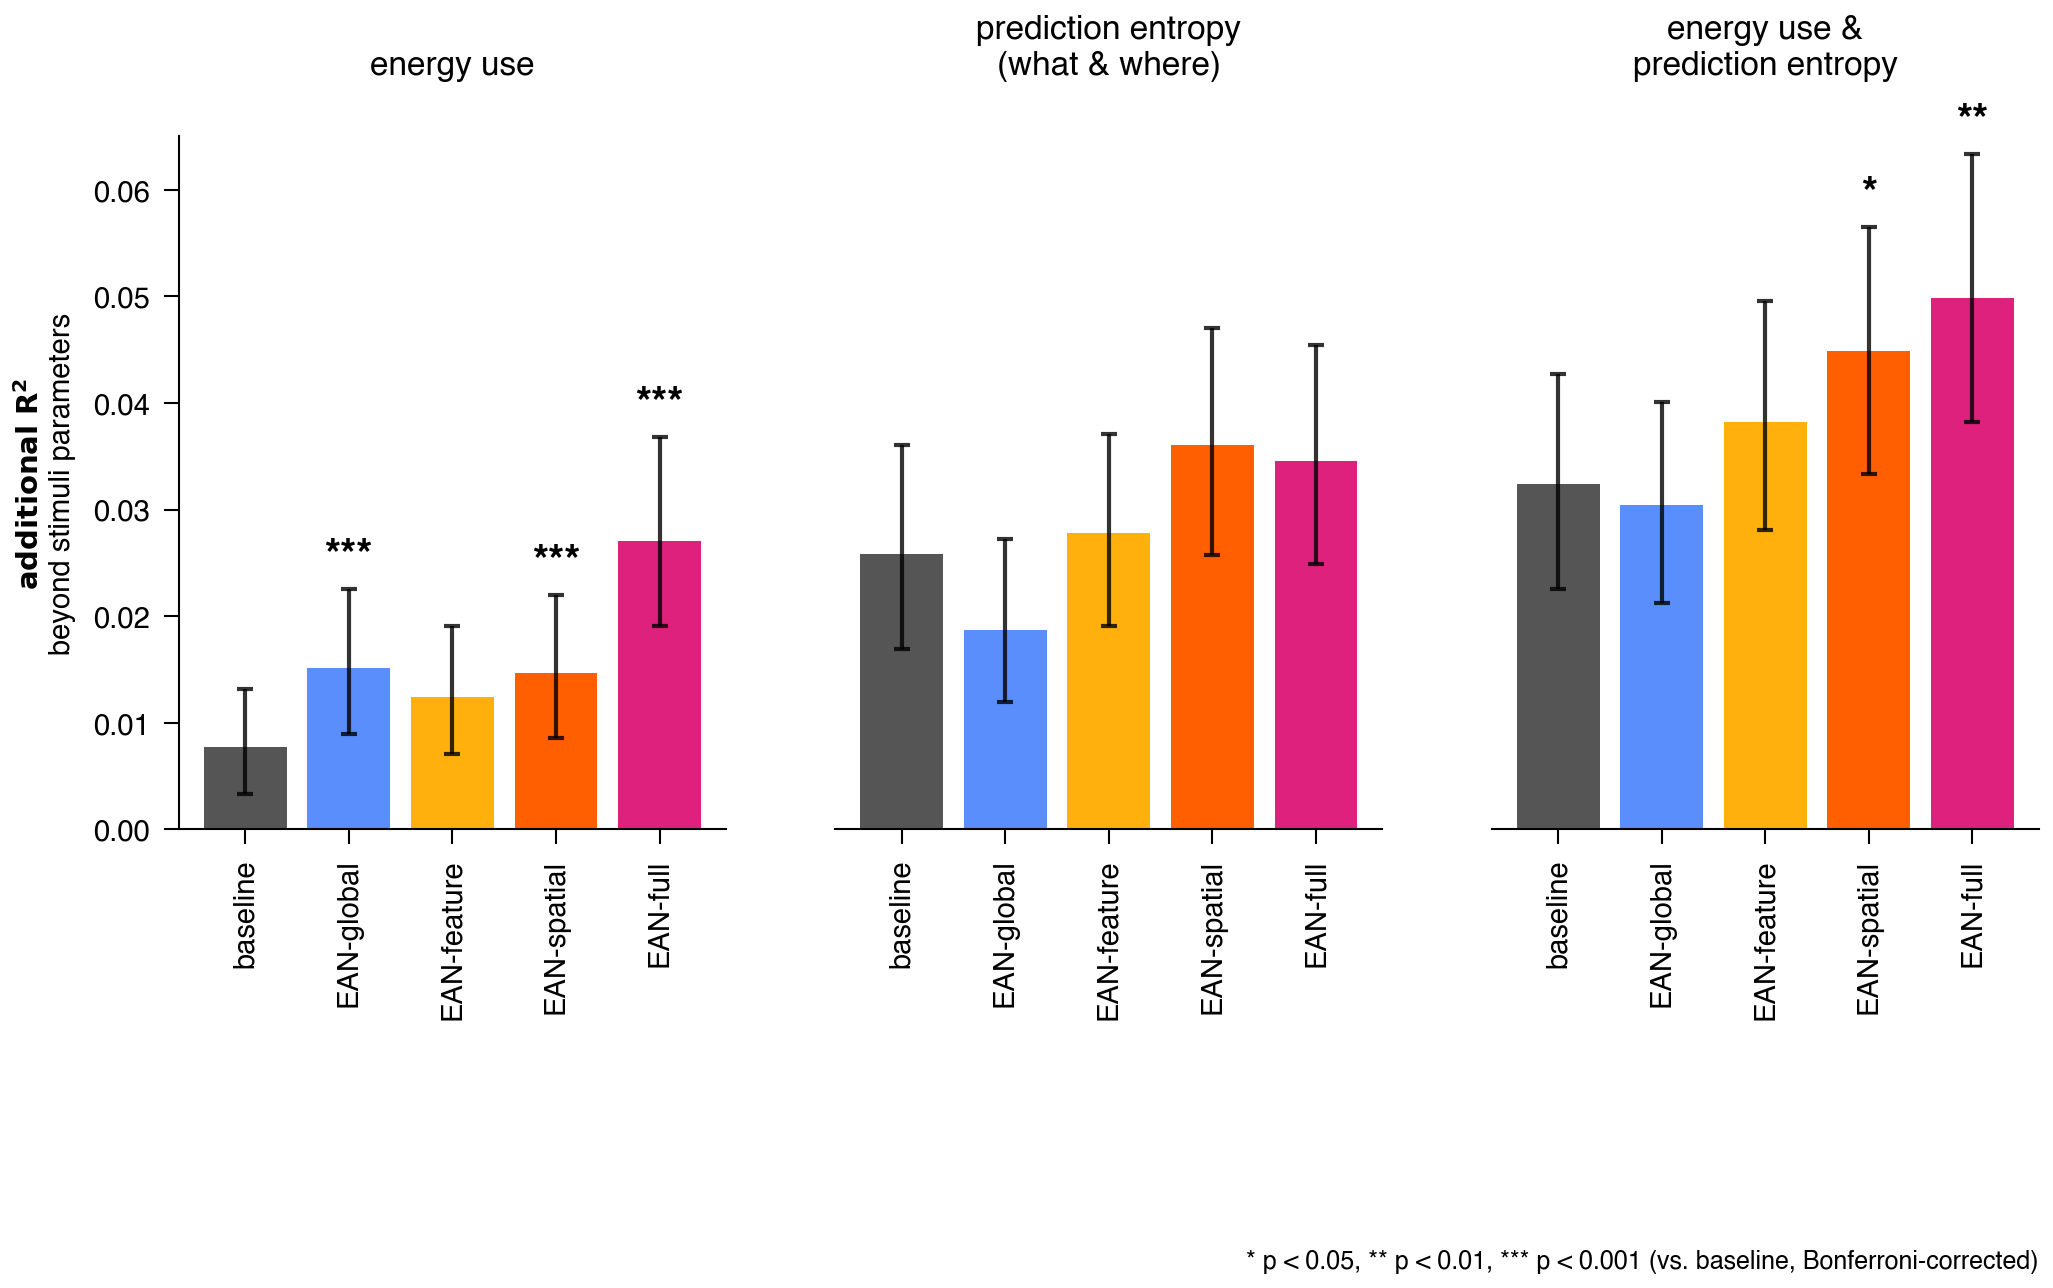

In [26]:
def plot_model_additional_variance_barplot(axs, difficulty_analysis_df, difficulty_statistical_test_results):
    """
    Create barplot showing additional variance explained by model energy use and entropy
    """
    
    # Calculate means and CIs across all energy costs and models
    metrics = ['energy_beyond_baseline_r2', 'entropy_beyond_baseline_r2', 'full_beyond_baseline_r2']
    titles = ["energy use", "prediction entropy\n(what & where)", "energy use &\nprediction entropy"]

    for (i, metric) in enumerate(metrics):
        means = []
        ci_lowers = []
        ci_uppers = []

        
        for model_name in MODEL_NAMES:
            # argmaxing the energy cost bin
            values = get_argmaxed_values(difficulty_analysis_df, model_name, metric, verbose=False)

            mean_val = values.mean()
            ci_lower = np.percentile(values, 2.5)
            ci_upper = np.percentile(values, 97.5)
            
            means.append(mean_val)
            ci_lowers.append(ci_lower)
            ci_uppers.append(ci_upper)

            print(metric, model_name, f"mean_val: {mean_val:.4f}, CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

        
        # Calculate error bars (distance from mean to CI bounds)
        yerr_lower = np.array(means) - np.array(ci_lowers)
        yerr_upper = np.array(ci_uppers) - np.array(means)
        yerr = [yerr_lower, yerr_upper]

        ax = axs[i]

        # colors = [constants.MODEL_COLORS[model] for model in constants.MODELS]
        colors = [seaborn_colors['palette'][j] for j in range(len(MODELS))]

        # Create bars
        bars = ax.bar(range(len(MODELS)), means, 
                    color=colors, alpha=1.0,
                    yerr=yerr, capsize=2, 
                    error_kw={'linewidth': 1, 'alpha': 0.8})
        
        # Formatting
        # ax.set_title("EAN's prediction entropy and energy use\nexplain ~4% additional variance in difficulty judgements", fontweight='bold', fontsize=14)
        if i == 0:
            # ax.set_ylabel('additional R²\nbeyond stimuli parameters')
            ax.set_ylabel(r'$\mathbf{additional\ R^2}$' + '\nbeyond stimuli parameters')
        ax.set_xticks(range(len(MODEL_NAMES)))
        ax.set_xticklabels(MODEL_NAMES, rotation=90)
        # ax.set_ylim(0, max(ci_uppers) * 1.1)  # Add some headroom
        ax.set_ylim(0, 0.065)
        ax.set_title(titles[i], pad=15)


        # statistically significant differences
        bootstrap_difference_test_df = difficulty_statistical_test_results[metric]

        # Add stars above the bars for significant differences to baseline
        for j, (model, bar, mean, ci_upper) in enumerate(zip(MODEL_NAMES, bars, means, ci_uppers)):
            if model == "baseline":
                continue  # Skip baseline
            # height = ci_upper + (max(ci_uppers) * 0.02)  # Slightly above error bar
            height = ci_upper + 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])  # Slightly above error bar
            p_corrected = bootstrap_difference_test_df[bootstrap_difference_test_df["model1"] == model]["p_value_corrected"].values[0]
            if p_corrected < 0.05:
                if p_corrected < 0.001:
                    stars = '***'
                elif p_corrected < 0.01:
                    stars = '**'
                elif p_corrected < 0.05:
                    stars = '*'

                ax.text(bar.get_x() + bar.get_width()/2., height,
                        # f'{mean:.3f}',
                        stars,
                        ha='center', va='bottom', fontsize=10, fontweight='bold')


        
        # Clean up spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if i > 0:
            ax.spines['left'].set_visible(False)
            ax.set_yticklabels([])
            ax.set_yticks([])
        # ax.grid(True, alpha=0.3, axis='y')
    # significance plotting explanation
    axs[2].text(
        1.0, -0.64,
        "* p < 0.05, ** p < 0.01, *** p < 0.001 (vs. baseline, Bonferroni-corrected)",
        ha='right', va='bottom', fontsize=6, transform=axs[2].transAxes
        )

# Usage:
# Create the plot
fig, axs = plt.subplots(1, 3, figsize=(8, 3))
plot_model_additional_variance_barplot(axs, bootstrap_difficulty_df, difficulty_statistical_test_results)
plt.show()

noise_r2 0.035224705815965936 0.022939131442077983 0.04963762937420257
n_distractors_r2 0.3516917160230495 0.323744830228507 0.3796499393637714
n_distractors_noise_r2 0.38843818542966935 0.36118460870877633 0.4151897135785065
energy_beyond_baseline_r2 baseline mean_val: 0.0077, CI: [0.0034, 0.0132]
energy_beyond_baseline_r2 EAN-global mean_val: 0.0152, CI: [0.0090, 0.0225]
energy_beyond_baseline_r2 EAN-feature mean_val: 0.0124, CI: [0.0071, 0.0191]
energy_beyond_baseline_r2 EAN-spatial mean_val: 0.0147, CI: [0.0086, 0.0220]
energy_beyond_baseline_r2 EAN-full mean_val: 0.0271, CI: [0.0191, 0.0368]
entropy_beyond_baseline_r2 baseline mean_val: 0.0258, CI: [0.0170, 0.0360]
entropy_beyond_baseline_r2 EAN-global mean_val: 0.0188, CI: [0.0120, 0.0273]
entropy_beyond_baseline_r2 EAN-feature mean_val: 0.0278, CI: [0.0190, 0.0371]
entropy_beyond_baseline_r2 EAN-spatial mean_val: 0.0361, CI: [0.0258, 0.0470]
entropy_beyond_baseline_r2 EAN-full mean_val: 0.0346, CI: [0.0249, 0.0455]
full_beyond_b

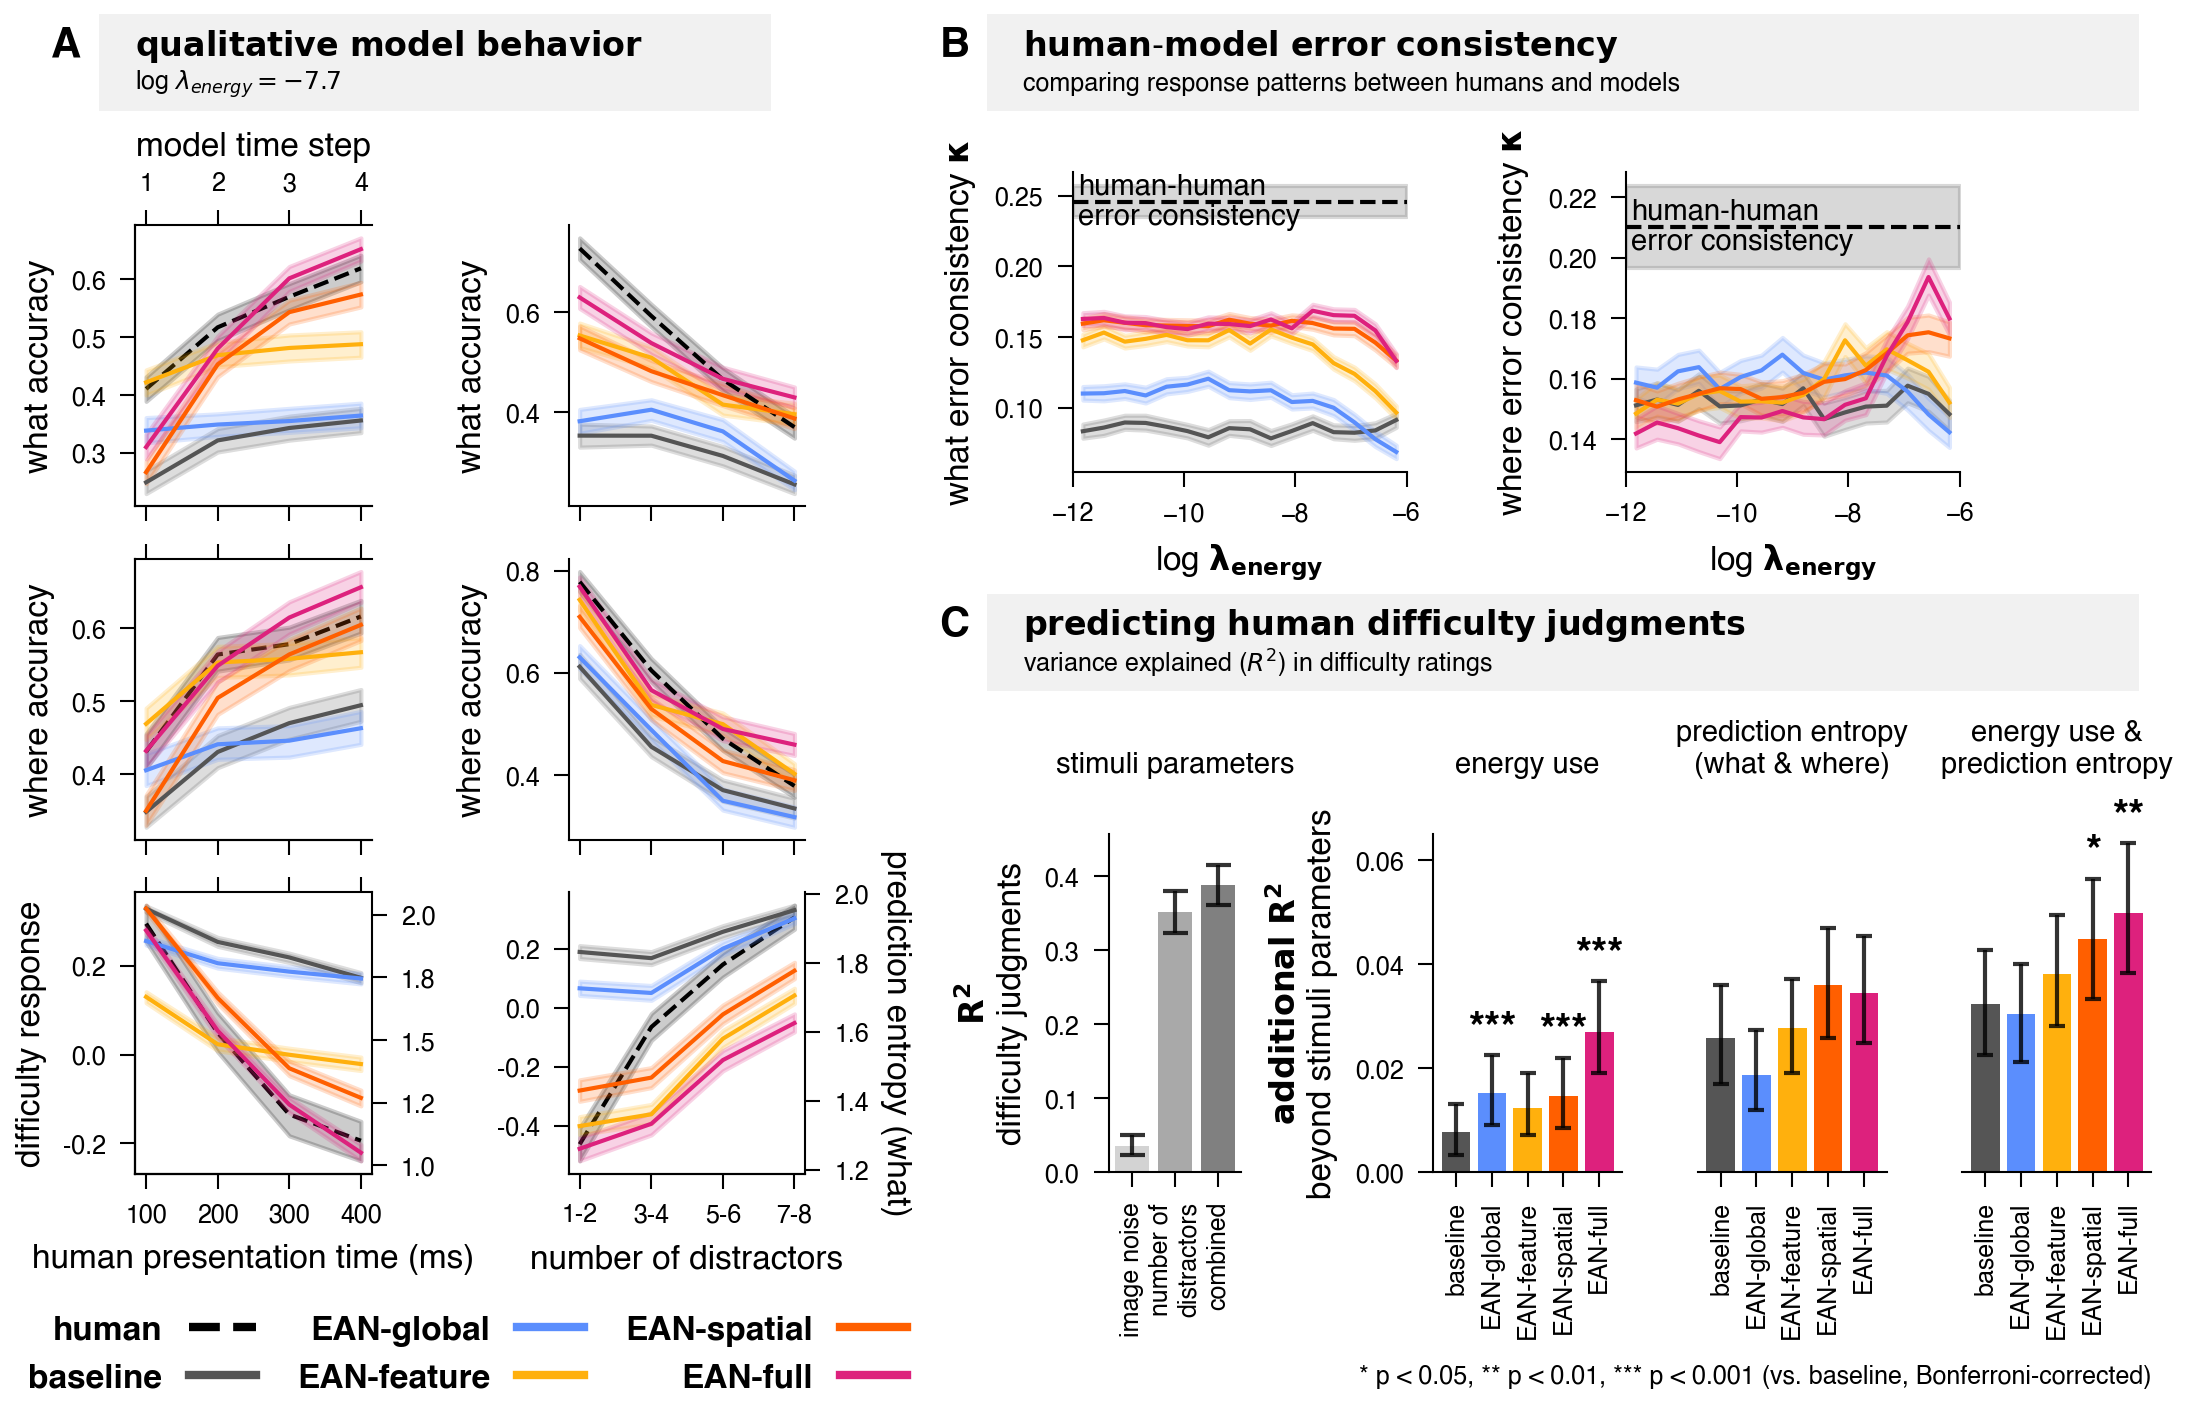

In [ ]:
from matplotlib.patches import FancyBboxPatch

label_fontsize = 8

# Create figure with custom gridspec layout using a 6x8 grid with spacer columns
fig = plt.figure(figsize=(8, 4.6))
gs = gridspec.GridSpec(6, 8,
                       width_ratios=[1.0, 0.5, 1.0, 1.0, 0.8, 0.8, 0.8, 0.8],
                       height_ratios=[1, 1, 1, 1, 1, 1])

# qualitative data in the first two columns with small spacer between them
axs = np.empty((3, 2), dtype=object)
axs[0, 0] = fig.add_subplot(gs[0:2, 0])    # row 0, col 0 spans rows 0-1
axs[0, 1] = fig.add_subplot(gs[0:2, 2])    # row 0, col 2 (after spacer) spans rows 0-1
axs[1, 0] = fig.add_subplot(gs[2:4, 0])    # row 1, col 0 spans rows 2-3
axs[1, 1] = fig.add_subplot(gs[2:4, 2])    # row 1, col 2 (after spacer) spans rows 2-3
axs[2, 0] = fig.add_subplot(gs[4:6, 0])    # row 2, col 0 spans rows 4-5
axs[2, 1] = fig.add_subplot(gs[4:6, 2])    # row 2, col 2 (after spacer) spans rows 4-5


# subplots for what and where error consistency in the f
axs_error_consistency = {}
axs_error_consistency["what"] = fig.add_subplot(gs[0:3, 4:6])    # what consistency spans rows 0-2
axs_error_consistency["where"] = fig.add_subplot(gs[0:3, 6:8])    # where consistency spans rows 0-2


axs_difficulty = {}
axs_difficulty["params"] = fig.add_subplot(gs[3:6, 4:5])
axs_difficulty["models_energy"] = fig.add_subplot(gs[3:6, 5:6])
axs_difficulty["models_entropy"] = fig.add_subplot(gs[3:6, 6:7])
axs_difficulty["models_combined"] = fig.add_subplot(gs[3:6, 7:8])

ax_legend = fig.add_subplot(gs[5, 2:])

fig.subplots_adjust(wspace=0.2, hspace=0.5)


# QUALITATIVE DATA IN THE FIRST TWO COLUMNS
# plot the qualitative data in the first two columns
plot_behavioral_data(axs[:,:2], human_df, model_df_plot=model_df, energy_cost=cfg.plotting.behavioral_results.qualitative_energy_cost, min_t=0)

for i in range(3):
    for j in range(2):
        ax = axs[i, j]
        pos = ax.get_position()
        ax.set_position([pos.x0, pos.y0 + (i+1)*0.03, pos.width, pos.height * 0.9])


# WHAT AND WHERE ERROR CONSISTENCY IN THE THIRD COLUMN
for i, task in enumerate(["what", "where"]):
    ax = axs_error_consistency[task]

    sns.lineplot(data=consistency_df,
                 x="energy_cost_bin",
                 y=f"{task}_kappa",
                 **seaborn_colors,
                 ax=ax,
                 linewidth=1)
    
    mean = np.mean(human_human_consistency[task])
    bootstrapped_means = [np.random.choice(human_human_consistency[task], 
                                        size=len(human_human_consistency[task]), 
                                        replace=True).mean() 
                       for _ in range(10000)]
    ci_human_lower = np.percentile(bootstrapped_means, 2.5)
    ci_human_upper = np.percentile(bootstrapped_means, 97.5)

    ax.set_xlim(-12, -6)
    xmin = ax.get_xlim()[0]
    xmax = ax.get_xlim()[1]

    ax.plot([xmin, xmax], [mean, mean], color="black", linestyle="--", zorder=-10, linewidth=1)
    ax.fill_between([xmin, xmax], [ci_human_lower, ci_human_lower], [ci_human_upper, ci_human_upper], color="gray", alpha=0.3, zorder=-11)
    ax.text(xmin+0.1, mean, f"human-human\nerror consistency", va='center', ha='left', color="black")

    ax.legend().remove()

    ax.set_ylabel(f"{task} error " + r"consistency $\mathbf{\kappa}$")
    ax.set_xlabel(r"log $\mathbf{\lambda_{energy}}$")




# make the second, third, fourth column lower height
for i, output in enumerate(["error_consistency", "difficulty"]):
    axs_output = axs_error_consistency if output=="error_consistency" else axs_difficulty
    for key, ax in axs_output.items():
        # ax = axs_error_consistency[task]
        extra_y_gap = 0.15
        height_factor = 0.75
        # pos = axs[i, j].get_position()
        pos = ax.get_position()

        new_height = pos.height * height_factor
        new_y0 = pos.y0 + (1 - height_factor) * pos.height * (i + 1) - extra_y_gap * i
        # new_y0 = pos.y0 + (1 - height_factor) * pos.height
        
        # Apply the new position
        # axs[i, j].set_position([pos.x0, new_y0, pos.width, new_height])
        ax.set_position([pos.x0, new_y0, pos.width, new_height])

# shift qualitative plots down
y_shift_qualitative = 0.09
for i in range(3):
    for j in range(2):
        pos = axs[i, j].get_position()
        new_y0 = pos.y0 - y_shift_qualitative
        axs[i, j].set_position([pos.x0, new_y0, pos.width, pos.height])

# shift consistency and difficulty plots down
y_shift_consistency = 0.04
for key, ax in axs_error_consistency.items():
    pos = ax.get_position()
    new_y0 = pos.y0 - y_shift_consistency
    ax.set_position([pos.x0, new_y0, pos.width, pos.height])

y_shift_difficulty = 0.07
for key, ax in axs_difficulty.items():
    pos = ax.get_position()
    new_y0 = pos.y0 - y_shift_difficulty
    ax.set_position([pos.x0, new_y0, pos.width, pos.height])


# adjusting consistency plots

pos = axs_error_consistency["what"].get_position()
new_x0 = pos.x0 - 0.02
new_y0 = pos.y0 + 0.05
new_width = pos.width * 0.8
new_height = pos.height * 0.8
axs_error_consistency["what"].set_position([new_x0, new_y0, new_width, new_height])

pos = axs_error_consistency["where"].get_position()
new_x0 = pos.x0 + 0.02
new_y0 = pos.y0 + 0.05
new_width = pos.width * 0.8
new_height = pos.height * 0.8
axs_error_consistency["where"].set_position([new_x0, new_y0, new_width, new_height])



plot_baseline_variance_barplot(axs_difficulty["params"], bootstrap_difficulty_df)

axs_additional_variance = [axs_difficulty[key] for key in ["models_energy", "models_entropy", "models_combined"]]
plot_model_additional_variance_barplot(axs_additional_variance, bootstrap_difficulty_df, difficulty_statistical_test_results)

for (i, key) in enumerate(["params", "models_energy", "models_entropy", "models_combined"]):
    if key in ["models_energy", "models_entropy", "models_combined"]:
        pos = axs_difficulty[key].get_position()
        new_width = pos.width * 1.0
        new_x0 = pos.x0 + i * 0.015 + 0.02
        new_y0 = pos.y0 + 0.04
        new_height = pos.height * 0.9
        axs_difficulty[key].set_position([new_x0, new_y0, new_width, new_height])
    else: # params
        pos = axs_difficulty[key].get_position()
        new_width = pos.width * 0.7
        new_x0 = pos.x0 - 0.005
        new_y0 = pos.y0 + 0.04
        new_height = pos.height * 0.9
        axs_difficulty[key].set_position([new_x0, new_y0, new_width, new_height])

# set fontsize for all axes
for ax in fig.get_axes():
    ax.title.set_fontsize(7)
    ax.xaxis.label.set_fontsize(label_fontsize)
    ax.yaxis.label.set_fontsize(label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=label_fontsize - 2)

# LEGEND (bottom row)
ax_legend.set(frame_on=False, xticks=[], yticks=[])

# add legend
legend_handles = []
legend_labels = []

# human
line = plt.Line2D([0], [0], color='black', lw=2, linestyle='--')
legend_handles.append(line)
legend_labels.append("human")

for i, model in enumerate(MODELS):
    line = plt.Line2D([0], [0], color=MODEL_COLORS[i], lw=2)
    legend_handles.append(line)
    legend_labels.append(MODEL_NAMES[i])

ax_legend.legend(
    legend_handles,
    legend_labels,
    loc='lower left',
    # ncol=1 + len(MODELS),
    ncol=3,
    # nrow=2,
    columnspacing=1.25,
    alignment='right',
    prop={
        'weight': 'bold',
        'size' : 8,
    },
    markerfirst=False,
    frameon=False,
    bbox_to_anchor=(-0.4, -2.0, 1.5, 1.0),
)

# Define global positions for the gray boxes and letters (in figure coordinates)
BOX_HEIGHT = 0.05  # Height to fit title + explanation
BOX_WIDTH_A = 0.26  # Width for box a (qualitative)
BOX_WIDTH_B = 0.46  # Width for box b (consistency)
BOX_WIDTH_C = 0.46  # Width for box c (difficulty) - narrower

# Box a: qualitative model behavior
BOX_X_A = 0.12
BOX_Y_A = 0.89
box_a = FancyBboxPatch((BOX_X_A, BOX_Y_A), BOX_WIDTH_A, BOX_HEIGHT,
                       boxstyle="square,pad=0.01",
                       transform=fig.transFigure,
                       facecolor='lightgray', alpha=0.3, edgecolor='none',
                       clip_on=False, zorder=-1)
fig.add_artist(box_a)

fig.text(BOX_X_A - 0.03, BOX_Y_A + BOX_HEIGHT * 0.75, "A", fontsize=10, fontweight='bold', va='center', ha='left')
fig.text(BOX_X_A + 0.005, BOX_Y_A + BOX_HEIGHT * 0.75, r"$\mathbf{qualitative\ model\ behavior}$", fontsize=8, 
         fontweight='normal', ha='left', va='center')
fig.text(BOX_X_A + 0.005, BOX_Y_A + BOX_HEIGHT * 0.2, r"log $\lambda_{energy} = -7.7$", fontsize=6, 
         fontweight='normal', ha='left', va='center')

# Box b: human-model error consistency
BOX_X_B = 0.49
BOX_Y_B = 0.89
box_b = FancyBboxPatch((BOX_X_B, BOX_Y_B), BOX_WIDTH_B, BOX_HEIGHT,
                       boxstyle="square,pad=0.01",
                       transform=fig.transFigure,
                       facecolor='lightgray', alpha=0.3, edgecolor='none',
                       clip_on=False, zorder=-1)
fig.add_artist(box_b)

fig.text(BOX_X_B - 0.03, BOX_Y_B + BOX_HEIGHT * 0.75, "B", fontsize=10, fontweight='bold', va='center', ha='left')
fig.text(BOX_X_B + 0.005, BOX_Y_B + BOX_HEIGHT * 0.75, r"$\mathbf{human\text{-}model\ error\ consistency}$", fontsize=8, 
         fontweight='normal', ha='left', va='center')
fig.text(BOX_X_B + 0.005, BOX_Y_B + BOX_HEIGHT * 0.2, r"comparing response patterns between humans and models", fontsize=6, 
         fontweight='normal', ha='left', va='center')

# Box c: predicting human difficulty judgments
BOX_X_C = 0.49
BOX_Y_C = 0.47
box_c = FancyBboxPatch((BOX_X_C, BOX_Y_C), BOX_WIDTH_C, BOX_HEIGHT,
                       boxstyle="square,pad=0.01",
                       transform=fig.transFigure,
                       facecolor='lightgray', alpha=0.3, edgecolor='none',
                       clip_on=False, zorder=-1)
fig.add_artist(box_c)

fig.text(BOX_X_C - 0.03, BOX_Y_C + BOX_HEIGHT * 0.75, "C", fontsize=10, fontweight='bold', va='center', ha='left')
fig.text(BOX_X_C + 0.005, BOX_Y_C + BOX_HEIGHT * 0.75, r"$\mathbf{predicting\ human\ difficulty\ judgments}$", fontsize=8, 
         fontweight='normal', ha='left', va='center')
fig.text(BOX_X_C + 0.005, BOX_Y_C + BOX_HEIGHT * 0.2, r"variance explained ($R^2$) in difficulty ratings", fontsize=6, 
         fontweight='normal', ha='left', va='center')

# don't save the old version
# fig.savefig(figures_dir / "fig5_model_human_behavior_comparison.pdf", dpi=500)
# fig.savefig(figures_dir / "fig5_model_human_behavior_comparison.png", dpi=500)

energy_beyond_baseline_r2 baseline mean_val: 0.0077, CI: [0.0034, 0.0132]
energy_beyond_baseline_r2 EAN-global mean_val: 0.0152, CI: [0.0090, 0.0225]
energy_beyond_baseline_r2 EAN-feature mean_val: 0.0124, CI: [0.0071, 0.0191]
energy_beyond_baseline_r2 EAN-spatial mean_val: 0.0147, CI: [0.0086, 0.0220]
energy_beyond_baseline_r2 EAN-full mean_val: 0.0271, CI: [0.0191, 0.0368]
entropy_beyond_baseline_r2 baseline mean_val: 0.0258, CI: [0.0170, 0.0360]
entropy_beyond_baseline_r2 EAN-global mean_val: 0.0188, CI: [0.0120, 0.0273]
entropy_beyond_baseline_r2 EAN-feature mean_val: 0.0278, CI: [0.0190, 0.0371]
entropy_beyond_baseline_r2 EAN-spatial mean_val: 0.0361, CI: [0.0258, 0.0470]
entropy_beyond_baseline_r2 EAN-full mean_val: 0.0346, CI: [0.0249, 0.0455]
full_beyond_baseline_r2 baseline mean_val: 0.0324, CI: [0.0225, 0.0427]
full_beyond_baseline_r2 EAN-global mean_val: 0.0305, CI: [0.0213, 0.0401]
full_beyond_baseline_r2 EAN-feature mean_val: 0.0382, CI: [0.0281, 0.0495]
full_beyond_baseli

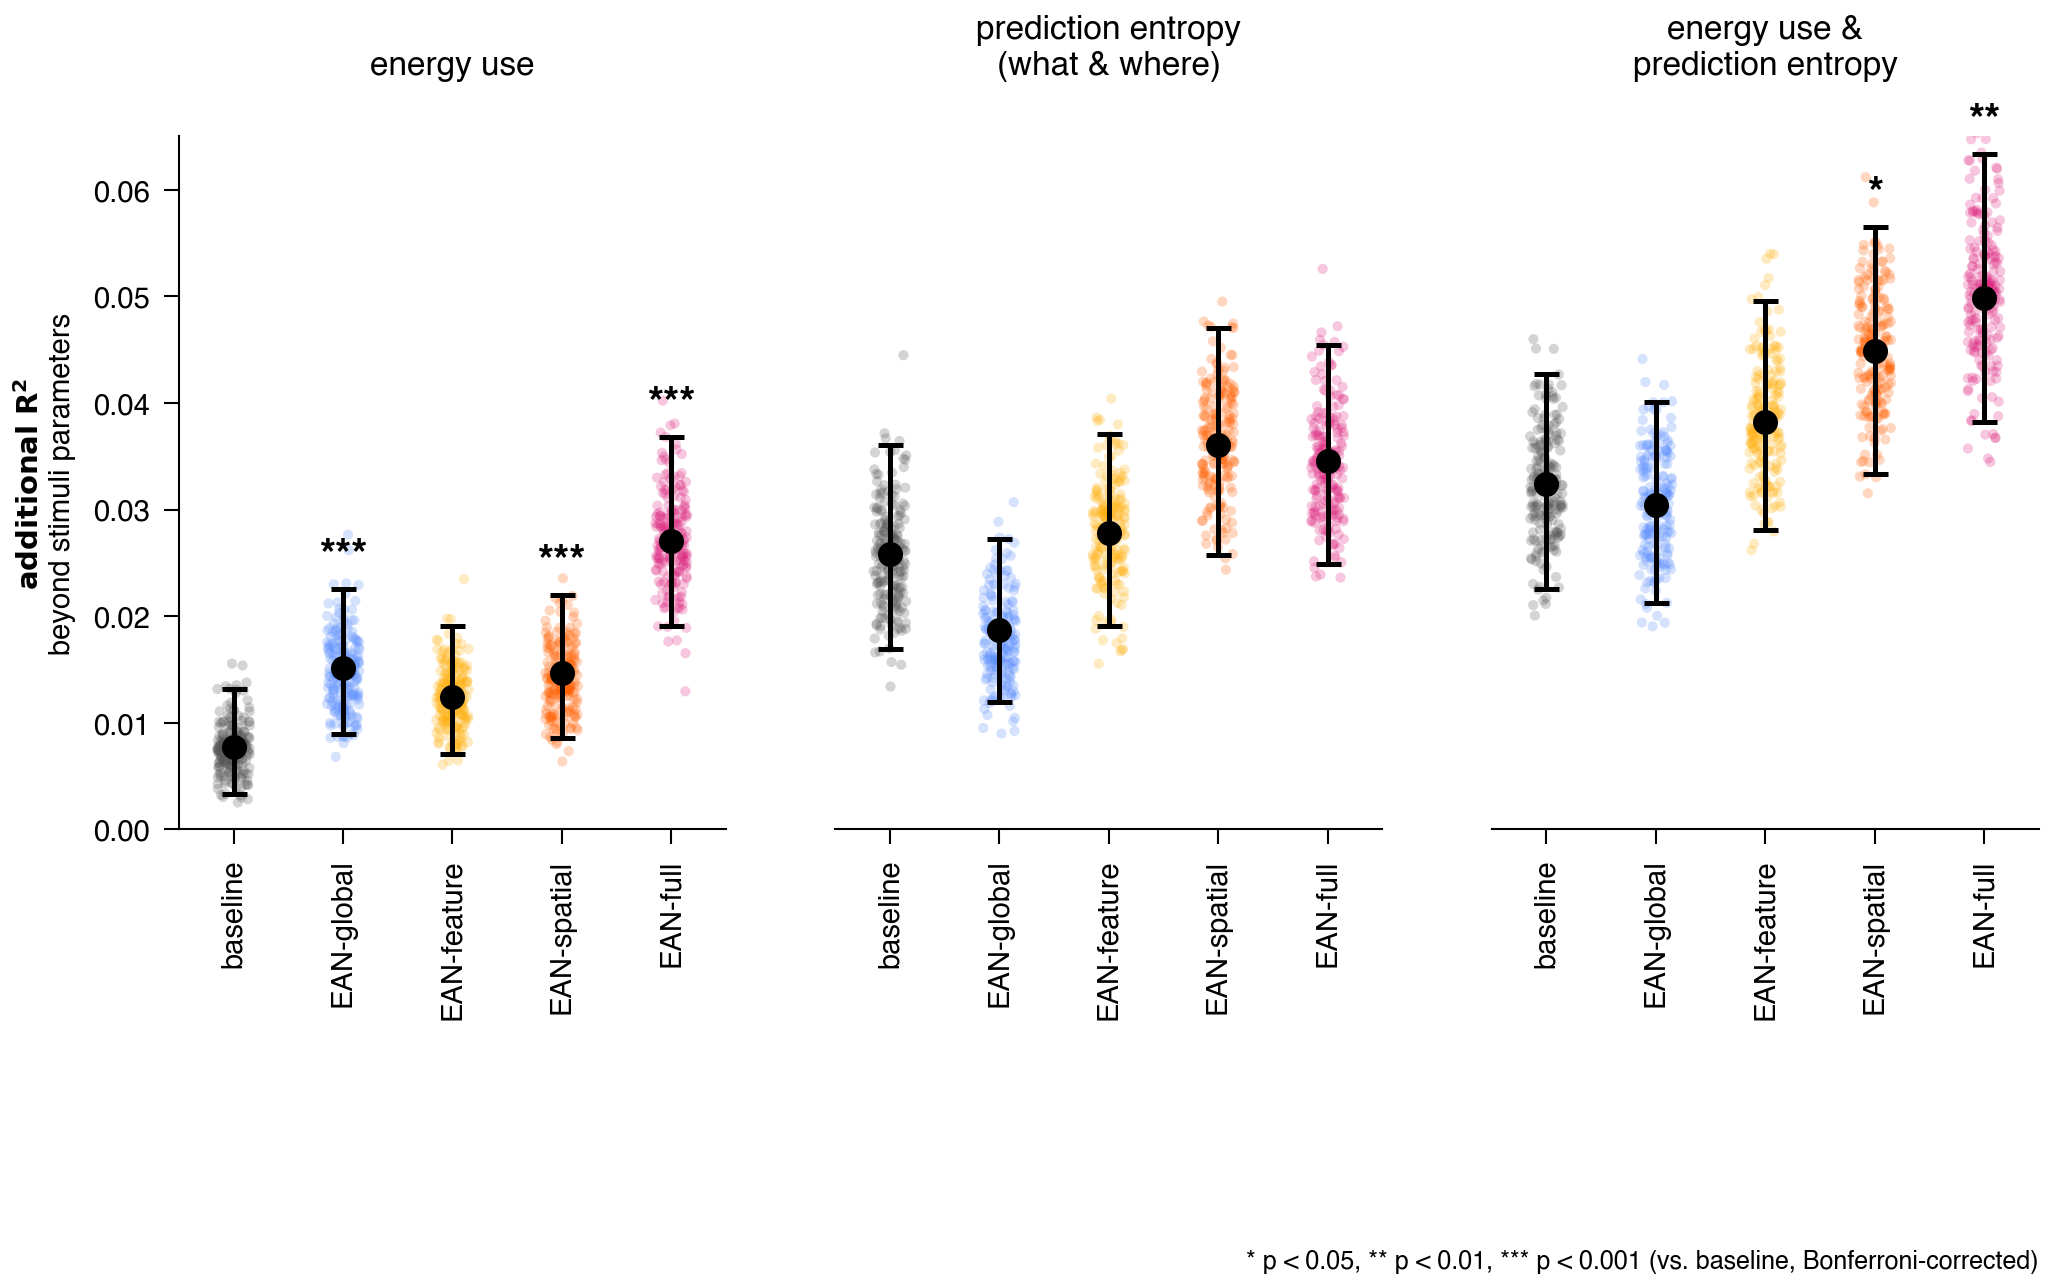

noise_r2 0.035224705815965936 0.022939131442077983 0.04963762937420257
n_distractors_r2 0.3516917160230495 0.323744830228507 0.3796499393637714
n_distractors_noise_r2 0.38843818542966935 0.36118460870877633 0.4151897135785065


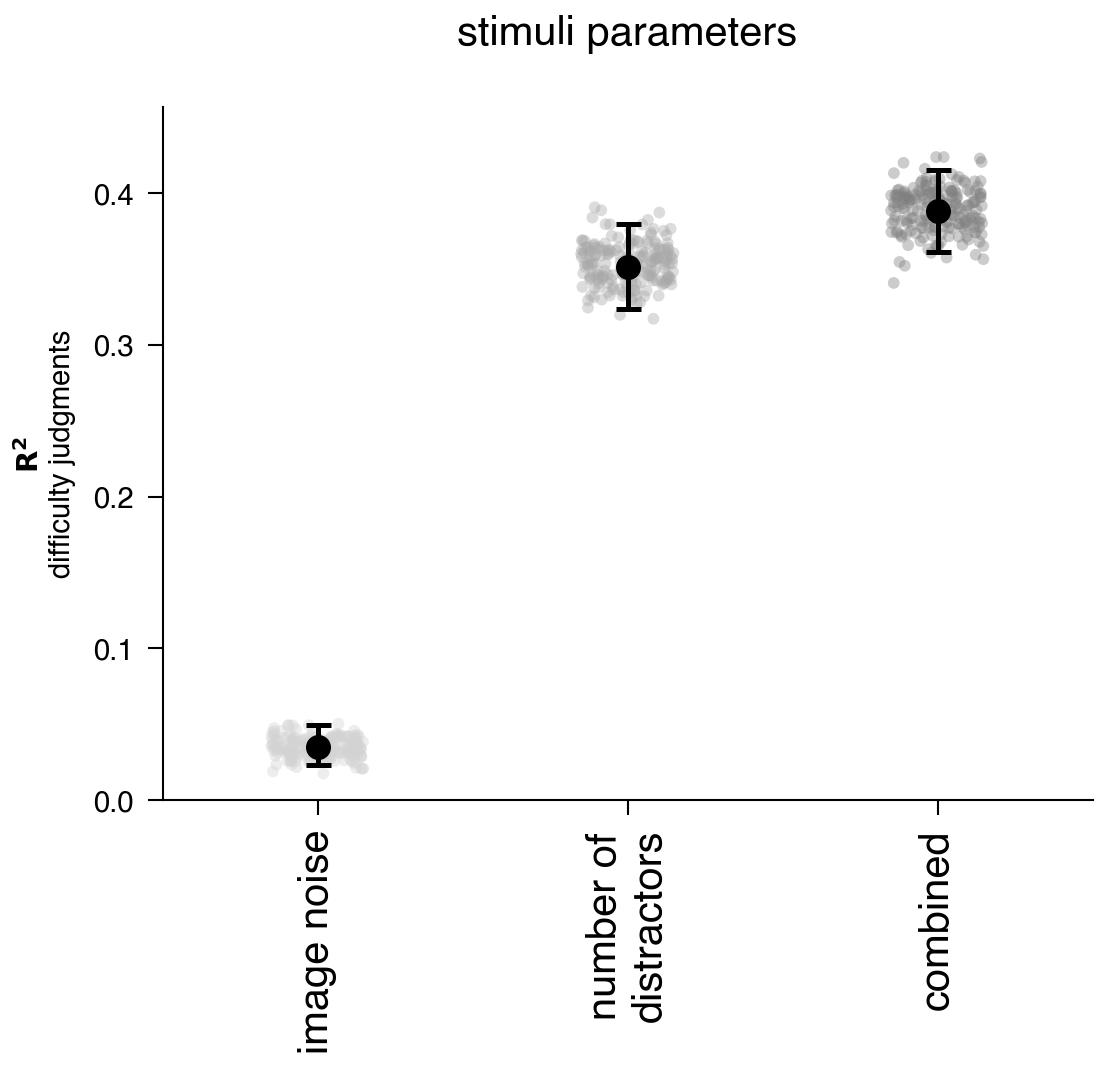

In [28]:
def plot_model_additional_variance_dotplot(axs, difficulty_analysis_df, difficulty_statistical_test_results):
    """
    Create dot plot showing additional variance explained by model energy use and entropy.
    Individual dots represent bootstrap samples; black markers show mean with 95% CI.
    """
    
    metrics = ['energy_beyond_baseline_r2', 'entropy_beyond_baseline_r2', 'full_beyond_baseline_r2']
    titles = ["energy use", "prediction entropy\n(what & where)", "energy use &\nprediction entropy"]

    for (i, metric) in enumerate(metrics):
        ax = axs[i]
        colors = [seaborn_colors['palette'][j] for j in range(len(MODELS))]
        
        means = []
        ci_lowers = []
        ci_uppers = []

        for j, model_name in enumerate(MODEL_NAMES):
            values = get_argmaxed_values(difficulty_analysis_df, model_name, metric, verbose=False)
            
            mean_val = values.mean()
            ci_lower = np.percentile(values, 2.5)
            ci_upper = np.percentile(values, 97.5)
            
            means.append(mean_val)
            ci_lowers.append(ci_lower)
            ci_uppers.append(ci_upper)
            
            print(metric, model_name, f"mean_val: {mean_val:.4f}, CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

            # Strip plot of bootstrap samples (jittered x-position for visibility)
            # Subsample if there are many bootstrap iterations to avoid overplotting
            n_show = min(len(values), 200)
            subsample = np.random.choice(values, size=n_show, replace=False) if len(values) > n_show else values
            jitter = np.random.uniform(-0.15, 0.15, size=len(subsample))
            ax.scatter(np.full(len(subsample), j) + jitter, subsample,
                      color=colors[j], alpha=0.25, s=6, edgecolors='none', zorder=2)

            # Mean with 95% CI error bar overlay
            ax.errorbar(j, mean_val,
                       yerr=[[mean_val - ci_lower], [ci_upper - mean_val]],
                       fmt='o', color='black', markersize=5,
                       capsize=3, capthick=1.2, elinewidth=1.2, zorder=3)

        # Formatting
        if i == 0:
            ax.set_ylabel(r'$\mathbf{additional\ R^2}$' + '\nbeyond stimuli parameters')
        ax.set_xticks(range(len(MODEL_NAMES)))
        ax.set_xticklabels(MODEL_NAMES, rotation=90)
        ax.set_xlim(-0.5, len(MODEL_NAMES) - 0.5)
        ax.set_ylim(0, 0.065)
        ax.set_title(titles[i], pad=15)

        # Significance stars
        bootstrap_difference_test_df = difficulty_statistical_test_results[metric]
        for j, (model, mean, ci_upper) in enumerate(zip(MODEL_NAMES, means, ci_uppers)):
            if model == "baseline":
                continue
            height = ci_upper + 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])
            p_corrected = bootstrap_difference_test_df[
                bootstrap_difference_test_df["model1"] == model
            ]["p_value_corrected"].values[0]
            if p_corrected < 0.05:
                if p_corrected < 0.001:
                    stars = '***'
                elif p_corrected < 0.01:
                    stars = '**'
                else:
                    stars = '*'
                ax.text(j, height, stars,
                       ha='center', va='bottom', fontsize=10, fontweight='bold')

        # Clean up spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if i > 0:
            ax.spines['left'].set_visible(False)
            ax.set_yticklabels([])
            ax.set_yticks([])

    # Significance legend
    axs[2].text(
        1.0, -0.64,
        "* p < 0.05, ** p < 0.01, *** p < 0.001 (vs. baseline, Bonferroni-corrected)",
        ha='right', va='bottom', fontsize=6, transform=axs[2].transAxes
    )


def plot_baseline_variance_dotplot(ax, difficulty_analysis_df):
    """
    Create dot plot showing variance explained by baseline image properties.
    Individual dots represent bootstrap samples; black markers show mean with 95% CI.
    """
    
    metrics = ['noise_r2', 'n_distractors_r2', 'n_distractors_noise_r2']
    labels = ['image noise', 'number of\ndistractors', 'combined']
    colors = ["lightgray", "darkgray", "gray"]
    
    means = []
    ci_uppers = []

    for i, metric in enumerate(metrics):
        values = difficulty_analysis_df[metric].values
        mean_val = values.mean()
        ci_lower = np.percentile(values, 2.5)
        ci_upper = np.percentile(values, 97.5)

        means.append(mean_val)
        ci_uppers.append(ci_upper)
        print(metric, mean_val, ci_lower, ci_upper)

        # Strip plot of bootstrap samples
        n_show = min(len(values), 200)
        subsample = np.random.choice(values, size=n_show, replace=False) if len(values) > n_show else values
        jitter = np.random.uniform(-0.15, 0.15, size=len(subsample))
        ax.scatter(np.full(len(subsample), i) + jitter, subsample,
                  color=colors[i], alpha=0.4, s=8, edgecolors='none', zorder=2)

        # Mean with 95% CI
        ax.errorbar(i, mean_val,
                   yerr=[[mean_val - ci_lower], [ci_upper - mean_val]],
                   fmt='o', color='black', markersize=5,
                   capsize=3, capthick=1.2, elinewidth=1.2, zorder=3)

    # Formatting
    ax.set_title('stimuli parameters', pad=15,
                fontsize=cfg.plotting.behavioral_results.difficulty.xlabel_fontsize)
    ax.set_ylabel(r'$\mathbf{R^2}$' + '\ndifficulty judgments')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90,
                      fontsize=cfg.plotting.behavioral_results.difficulty.xlabel_fontsize)
    ax.set_xlim(-0.5, len(metrics) - 0.5)
    ax.set_ylim(0, max(ci_uppers) * 1.1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# Usage (unchanged)
fig, axs = plt.subplots(1, 3, figsize=(8, 3))
plot_model_additional_variance_dotplot(axs, bootstrap_difficulty_df, difficulty_statistical_test_results)
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
plot_baseline_variance_dotplot(ax, bootstrap_difficulty_df)
plt.show()

noise_r2 0.035224705815965936 0.022939131442077983 0.04963762937420257
n_distractors_r2 0.3516917160230495 0.323744830228507 0.3796499393637714
n_distractors_noise_r2 0.38843818542966935 0.36118460870877633 0.4151897135785065
energy_beyond_baseline_r2 baseline mean_val: 0.0077, CI: [0.0034, 0.0132]
energy_beyond_baseline_r2 EAN-global mean_val: 0.0152, CI: [0.0090, 0.0225]
energy_beyond_baseline_r2 EAN-feature mean_val: 0.0124, CI: [0.0071, 0.0191]
energy_beyond_baseline_r2 EAN-spatial mean_val: 0.0147, CI: [0.0086, 0.0220]
energy_beyond_baseline_r2 EAN-full mean_val: 0.0271, CI: [0.0191, 0.0368]
entropy_beyond_baseline_r2 baseline mean_val: 0.0258, CI: [0.0170, 0.0360]
entropy_beyond_baseline_r2 EAN-global mean_val: 0.0188, CI: [0.0120, 0.0273]
entropy_beyond_baseline_r2 EAN-feature mean_val: 0.0278, CI: [0.0190, 0.0371]
entropy_beyond_baseline_r2 EAN-spatial mean_val: 0.0361, CI: [0.0258, 0.0470]
entropy_beyond_baseline_r2 EAN-full mean_val: 0.0346, CI: [0.0249, 0.0455]
full_beyond_b

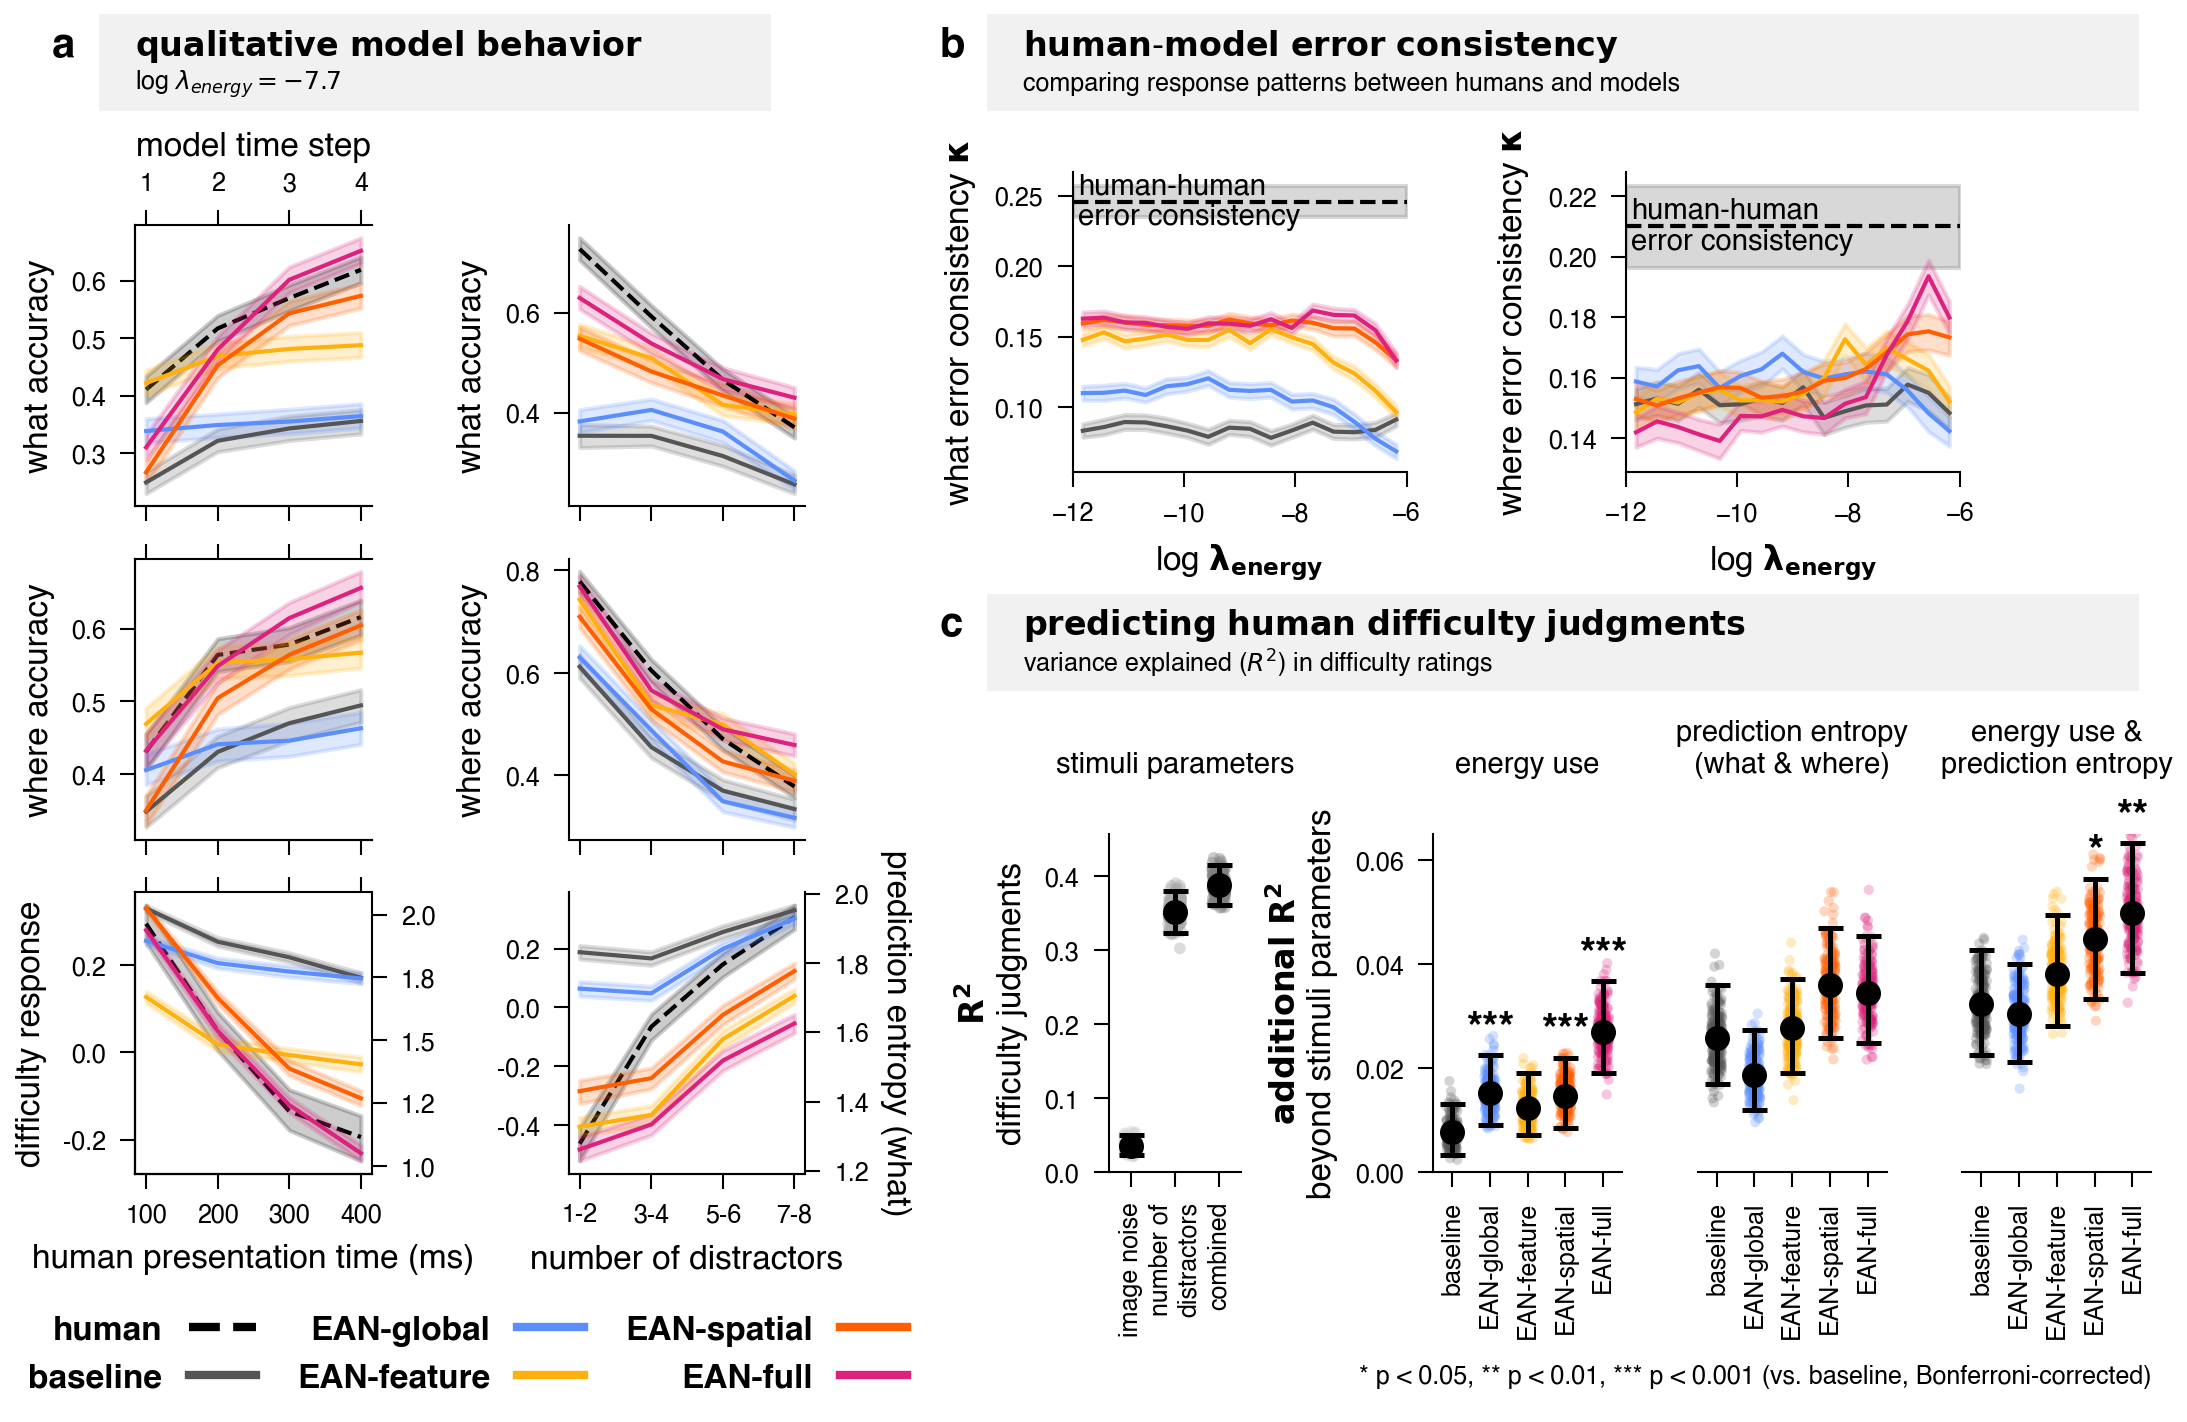

In [34]:
from matplotlib.patches import FancyBboxPatch

label_fontsize = 8

# Create figure with custom gridspec layout using a 6x8 grid with spacer columns
fig = plt.figure(figsize=(8, 4.6))
gs = gridspec.GridSpec(6, 8,
                       width_ratios=[1.0, 0.5, 1.0, 1.0, 0.8, 0.8, 0.8, 0.8],
                       height_ratios=[1, 1, 1, 1, 1, 1])

# qualitative data in the first two columns with small spacer between them
axs = np.empty((3, 2), dtype=object)
axs[0, 0] = fig.add_subplot(gs[0:2, 0])    # row 0, col 0 spans rows 0-1
axs[0, 1] = fig.add_subplot(gs[0:2, 2])    # row 0, col 2 (after spacer) spans rows 0-1
axs[1, 0] = fig.add_subplot(gs[2:4, 0])    # row 1, col 0 spans rows 2-3
axs[1, 1] = fig.add_subplot(gs[2:4, 2])    # row 1, col 2 (after spacer) spans rows 2-3
axs[2, 0] = fig.add_subplot(gs[4:6, 0])    # row 2, col 0 spans rows 4-5
axs[2, 1] = fig.add_subplot(gs[4:6, 2])    # row 2, col 2 (after spacer) spans rows 4-5


# subplots for what and where error consistency in the f
axs_error_consistency = {}
axs_error_consistency["what"] = fig.add_subplot(gs[0:3, 4:6])    # what consistency spans rows 0-2
axs_error_consistency["where"] = fig.add_subplot(gs[0:3, 6:8])    # where consistency spans rows 0-2


axs_difficulty = {}
axs_difficulty["params"] = fig.add_subplot(gs[3:6, 4:5])
axs_difficulty["models_energy"] = fig.add_subplot(gs[3:6, 5:6])
axs_difficulty["models_entropy"] = fig.add_subplot(gs[3:6, 6:7])
axs_difficulty["models_combined"] = fig.add_subplot(gs[3:6, 7:8])

ax_legend = fig.add_subplot(gs[5, 2:])

fig.subplots_adjust(wspace=0.2, hspace=0.5)


# QUALITATIVE DATA IN THE FIRST TWO COLUMNS
# plot the qualitative data in the first two columns
plot_behavioral_data(axs[:,:2], human_df, model_df_plot=model_df, energy_cost=cfg.plotting.behavioral_results.qualitative_energy_cost, min_t=0)

for i in range(3):
    for j in range(2):
        ax = axs[i, j]
        pos = ax.get_position()
        ax.set_position([pos.x0, pos.y0 + (i+1)*0.03, pos.width, pos.height * 0.9])


# WHAT AND WHERE ERROR CONSISTENCY IN THE THIRD COLUMN
for i, task in enumerate(["what", "where"]):
    ax = axs_error_consistency[task]

    sns.lineplot(data=consistency_df,
                 x="energy_cost_bin",
                 y=f"{task}_kappa",
                 **seaborn_colors,
                 ax=ax,
                 linewidth=1)
    
    mean = np.mean(human_human_consistency[task])
    bootstrapped_means = [np.random.choice(human_human_consistency[task], 
                                        size=len(human_human_consistency[task]), 
                                        replace=True).mean() 
                       for _ in range(10000)]
    ci_human_lower = np.percentile(bootstrapped_means, 2.5)
    ci_human_upper = np.percentile(bootstrapped_means, 97.5)

    ax.set_xlim(-12, -6)
    xmin = ax.get_xlim()[0]
    xmax = ax.get_xlim()[1]

    ax.plot([xmin, xmax], [mean, mean], color="black", linestyle="--", zorder=-10, linewidth=1)
    ax.fill_between([xmin, xmax], [ci_human_lower, ci_human_lower], [ci_human_upper, ci_human_upper], color="gray", alpha=0.3, zorder=-11)
    ax.text(xmin+0.1, mean, f"human-human\nerror consistency", va='center', ha='left', color="black")

    ax.legend().remove()

    ax.set_ylabel(f"{task} error " + r"consistency $\mathbf{\kappa}$")
    ax.set_xlabel(r"log $\mathbf{\lambda_{energy}}$")




# make the second, third, fourth column lower height
for i, output in enumerate(["error_consistency", "difficulty"]):
    axs_output = axs_error_consistency if output=="error_consistency" else axs_difficulty
    for key, ax in axs_output.items():
        # ax = axs_error_consistency[task]
        extra_y_gap = 0.15
        height_factor = 0.75
        # pos = axs[i, j].get_position()
        pos = ax.get_position()

        new_height = pos.height * height_factor
        new_y0 = pos.y0 + (1 - height_factor) * pos.height * (i + 1) - extra_y_gap * i
        # new_y0 = pos.y0 + (1 - height_factor) * pos.height
        
        # Apply the new position
        # axs[i, j].set_position([pos.x0, new_y0, pos.width, new_height])
        ax.set_position([pos.x0, new_y0, pos.width, new_height])

# shift qualitative plots down
y_shift_qualitative = 0.09
for i in range(3):
    for j in range(2):
        pos = axs[i, j].get_position()
        new_y0 = pos.y0 - y_shift_qualitative
        axs[i, j].set_position([pos.x0, new_y0, pos.width, pos.height])

# shift consistency and difficulty plots down
y_shift_consistency = 0.04
for key, ax in axs_error_consistency.items():
    pos = ax.get_position()
    new_y0 = pos.y0 - y_shift_consistency
    ax.set_position([pos.x0, new_y0, pos.width, pos.height])

y_shift_difficulty = 0.07
for key, ax in axs_difficulty.items():
    pos = ax.get_position()
    new_y0 = pos.y0 - y_shift_difficulty
    ax.set_position([pos.x0, new_y0, pos.width, pos.height])


# adjusting consistency plots

pos = axs_error_consistency["what"].get_position()
new_x0 = pos.x0 - 0.02
new_y0 = pos.y0 + 0.05
new_width = pos.width * 0.8
new_height = pos.height * 0.8
axs_error_consistency["what"].set_position([new_x0, new_y0, new_width, new_height])

pos = axs_error_consistency["where"].get_position()
new_x0 = pos.x0 + 0.02
new_y0 = pos.y0 + 0.05
new_width = pos.width * 0.8
new_height = pos.height * 0.8
axs_error_consistency["where"].set_position([new_x0, new_y0, new_width, new_height])



plot_baseline_variance_dotplot(axs_difficulty["params"], bootstrap_difficulty_df)


axs_additional_variance = [axs_difficulty[key] for key in ["models_energy", "models_entropy", "models_combined"]]
plot_model_additional_variance_dotplot(axs_additional_variance, bootstrap_difficulty_df, difficulty_statistical_test_results)

for (i, key) in enumerate(["params", "models_energy", "models_entropy", "models_combined"]):
    if key in ["models_energy", "models_entropy", "models_combined"]:
        pos = axs_difficulty[key].get_position()
        new_width = pos.width * 1.0
        new_x0 = pos.x0 + i * 0.015 + 0.02
        new_y0 = pos.y0 + 0.04
        new_height = pos.height * 0.9
        axs_difficulty[key].set_position([new_x0, new_y0, new_width, new_height])
    else: # params
        pos = axs_difficulty[key].get_position()
        new_width = pos.width * 0.7
        new_x0 = pos.x0 - 0.005
        new_y0 = pos.y0 + 0.04
        new_height = pos.height * 0.9
        axs_difficulty[key].set_position([new_x0, new_y0, new_width, new_height])

# set fontsize for all axes
for ax in fig.get_axes():
    ax.title.set_fontsize(7)
    ax.xaxis.label.set_fontsize(label_fontsize)
    ax.yaxis.label.set_fontsize(label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=label_fontsize - 2)

# LEGEND (bottom row)
ax_legend.set(frame_on=False, xticks=[], yticks=[])

# add legend
legend_handles = []
legend_labels = []

# human
line = plt.Line2D([0], [0], color='black', lw=2, linestyle='--')
legend_handles.append(line)
legend_labels.append("human")

for i, model in enumerate(MODELS):
    line = plt.Line2D([0], [0], color=MODEL_COLORS[i], lw=2)
    legend_handles.append(line)
    legend_labels.append(MODEL_NAMES[i])

ax_legend.legend(
    legend_handles,
    legend_labels,
    loc='lower left',
    # ncol=1 + len(MODELS),
    ncol=3,
    # nrow=2,
    columnspacing=1.25,
    alignment='right',
    prop={
        'weight': 'bold',
        'size' : 8,
    },
    markerfirst=False,
    frameon=False,
    bbox_to_anchor=(-0.4, -2.0, 1.5, 1.0),
)

# Define global positions for the gray boxes and letters (in figure coordinates)
BOX_HEIGHT = 0.05  # Height to fit title + explanation
BOX_WIDTH_A = 0.26  # Width for box a (qualitative)
BOX_WIDTH_B = 0.46  # Width for box b (consistency)
BOX_WIDTH_C = 0.46  # Width for box c (difficulty) - narrower

# Box a: qualitative model behavior
BOX_X_A = 0.12
BOX_Y_A = 0.89
box_a = FancyBboxPatch((BOX_X_A, BOX_Y_A), BOX_WIDTH_A, BOX_HEIGHT,
                       boxstyle="square,pad=0.01",
                       transform=fig.transFigure,
                       facecolor='lightgray', alpha=0.3, edgecolor='none',
                       clip_on=False, zorder=-1)
fig.add_artist(box_a)

fig.text(BOX_X_A - 0.03, BOX_Y_A + BOX_HEIGHT * 0.75, "a", fontsize=10, fontweight='bold', va='center', ha='left')
fig.text(BOX_X_A + 0.005, BOX_Y_A + BOX_HEIGHT * 0.75, r"$\mathbf{qualitative\ model\ behavior}$", fontsize=8, 
         fontweight='normal', ha='left', va='center')
fig.text(BOX_X_A + 0.005, BOX_Y_A + BOX_HEIGHT * 0.2, r"log $\lambda_{energy} = -7.7$", fontsize=6, 
         fontweight='normal', ha='left', va='center')

# Box b: human-model error consistency
BOX_X_B = 0.49
BOX_Y_B = 0.89
box_b = FancyBboxPatch((BOX_X_B, BOX_Y_B), BOX_WIDTH_B, BOX_HEIGHT,
                       boxstyle="square,pad=0.01",
                       transform=fig.transFigure,
                       facecolor='lightgray', alpha=0.3, edgecolor='none',
                       clip_on=False, zorder=-1)
fig.add_artist(box_b)

fig.text(BOX_X_B - 0.03, BOX_Y_B + BOX_HEIGHT * 0.75, "b", fontsize=10, fontweight='bold', va='center', ha='left')
fig.text(BOX_X_B + 0.005, BOX_Y_B + BOX_HEIGHT * 0.75, r"$\mathbf{human\text{-}model\ error\ consistency}$", fontsize=8, 
         fontweight='normal', ha='left', va='center')
fig.text(BOX_X_B + 0.005, BOX_Y_B + BOX_HEIGHT * 0.2, r"comparing response patterns between humans and models", fontsize=6, 
         fontweight='normal', ha='left', va='center')

# Box c: predicting human difficulty judgments
BOX_X_C = 0.49
BOX_Y_C = 0.47
box_c = FancyBboxPatch((BOX_X_C, BOX_Y_C), BOX_WIDTH_C, BOX_HEIGHT,
                       boxstyle="square,pad=0.01",
                       transform=fig.transFigure,
                       facecolor='lightgray', alpha=0.3, edgecolor='none',
                       clip_on=False, zorder=-1)
fig.add_artist(box_c)

fig.text(BOX_X_C - 0.03, BOX_Y_C + BOX_HEIGHT * 0.75, "c", fontsize=10, fontweight='bold', va='center', ha='left')
fig.text(BOX_X_C + 0.005, BOX_Y_C + BOX_HEIGHT * 0.75, r"$\mathbf{predicting\ human\ difficulty\ judgments}$", fontsize=8, 
         fontweight='normal', ha='left', va='center')
fig.text(BOX_X_C + 0.005, BOX_Y_C + BOX_HEIGHT * 0.2, r"variance explained ($R^2$) in difficulty ratings", fontsize=6, 
         fontweight='normal', ha='left', va='center')


fig.savefig(figures_dir / "fig5_model_human_behavior_comparison.pdf", dpi=500)
fig.savefig(figures_dir / "fig5_model_human_behavior_comparison.png", dpi=500)

In [30]:
bootstrap_difficulty_df.columns

Index(['noise_r2', 'n_distractors_r2', 'n_distractors_noise_r2', 'energy_r2',
       'energy_beyond_baseline_r2', 'entropy_r2', 'entropy_beyond_baseline_r2',
       'full_r2', 'full_beyond_baseline_r2', 'model_name', 'energy_cost_bin'],
      dtype='object')

In [31]:
list(difficulty_statistical_test_results.keys())

['energy_beyond_baseline_r2',
 'entropy_beyond_baseline_r2',
 'full_beyond_baseline_r2']

In [32]:
difficulty_statistical_test_results['energy_beyond_baseline_r2'].columns

Index(['model1', 'model2', 'observed_diff', 'ci_lower', 'ci_upper', 'p_value',
       'significant', 'cohens_d', 'n_bootstrap', 'mean_model1', 'mean_model2',
       'std_model1', 'std_model2', 'p_value_corrected',
       'significant_corrected', 'correction_method'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np


def generate_full_stats_table(
    difficulty_statistical_test_results,
    bootstrap_difficulty_df,
    model_names,
    get_argmaxed_values,
):
    metric_info = {
        'energy_beyond_baseline_r2': {
            'label': 'Energy use',
            'df_resid': 385,
        },
        'entropy_beyond_baseline_r2': {
            'label': 'Prediction entropy',
            'df_resid': 384,
        },
        'full_beyond_baseline_r2': {
            'label': 'Energy use + entropy',
            'df_resid': 383,
        },
    }
    
    def format_p(p):
        if pd.isna(p):
            return '---'
        if p < 0.001:
            return '$<0.001$'
        return f"${p:.3f}$"
    
    def get_model_ci(model_name, metric):
        values = get_argmaxed_values(
            bootstrap_difficulty_df, model_name, metric, verbose=False
        )
        return values.mean(), np.percentile(values, 2.5), np.percentile(values, 97.5)
    
    rows = []
    for metric_key, info in metric_info.items():
        metric_label = info['label']
        df_resid = info['df_resid']
        test_df = difficulty_statistical_test_results[metric_key]
        
        for model_name in model_names:
            mean_dr2, ci_lo_dr2, ci_hi_dr2 = get_model_ci(model_name, metric_key)
            
            if model_name == 'baseline':
                rows.append({
                    'Covariate set': metric_label,
                    'Model': 'baseline',
                    '$\\Delta R^2$ [95\\% CI]': f"${mean_dr2:.4f}$ $[{ci_lo_dr2:.4f}, {ci_hi_dr2:.4f}]$",
                    'Diff. vs. baseline [95\\% CI]': '---',
                    '$p$ (corrected)': '---',
                    'df': df_resid,
                })
            else:
                row = test_df[test_df['model1'] == model_name].iloc[0]
                rows.append({
                    'Covariate set': metric_label,
                    'Model': model_name,
                    '$\\Delta R^2$ [95\\% CI]': f"${mean_dr2:.4f}$ $[{ci_lo_dr2:.4f}, {ci_hi_dr2:.4f}]$",
                    'Diff. vs. baseline [95\\% CI]': (
                        f"${row['observed_diff']:.4f}$ "
                        f"$[{row['ci_lower']:.4f}, {row['ci_upper']:.4f}]$"
                    ),
                    '$p$ (corrected)': format_p(row['p_value_corrected']),
                    'df': df_resid,
                })
    
    return pd.DataFrame(rows)


MODEL_NAMES = ['baseline', 'EAN-global', 'EAN-feature', 'EAN-spatial', 'EAN-full']

table = generate_full_stats_table(
    difficulty_statistical_test_results,
    bootstrap_difficulty_df,
    MODEL_NAMES,
    get_argmaxed_values,
)

# Export LaTeX — escape=False because we want our $ and \\ to survive
with open('fig5c_stats_table.tex', 'w') as f:
    f.write(table.to_latex(index=False, escape=False, column_format='llllll'))

# Also CSV for archival
table.to_csv('fig5c_stats_table.csv', index=False)

# Preview
print(table.to_string(index=False))
print("\nExported to fig5c_stats_table.{tex, csv}")

       Covariate set       Model      $\Delta R^2$ [95\% CI]  Diff. vs. baseline [95\% CI] $p$ (corrected)  df
          Energy use    baseline $0.0077$ $[0.0034, 0.0132]$                           ---             --- 385
          Energy use  EAN-global $0.0152$ $[0.0090, 0.0225]$   $0.0075$ $[0.0045, 0.0106]$        $<0.001$ 385
          Energy use EAN-feature $0.0124$ $[0.0071, 0.0191]$   $0.0047$ $[0.0007, 0.0094]$         $0.177$ 385
          Energy use EAN-spatial $0.0147$ $[0.0086, 0.0220]$   $0.0069$ $[0.0039, 0.0102]$        $<0.001$ 385
          Energy use    EAN-full $0.0271$ $[0.0191, 0.0368]$   $0.0193$ $[0.0136, 0.0259]$        $<0.001$ 385
  Prediction entropy    baseline $0.0258$ $[0.0170, 0.0360]$                           ---             --- 384
  Prediction entropy  EAN-global $0.0188$ $[0.0120, 0.0273]$ $-0.0071$ $[-0.0151, 0.0008]$         $0.332$ 384
  Prediction entropy EAN-feature $0.0278$ $[0.0190, 0.0371]$  $0.0020$ $[-0.0077, 0.0118]$         $1.000$ 384
 